In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit
from scipy.stats import norm
from IPython.display import Image, display

import gc
import itertools

plt.rcParams['font.size'] = 16

In [2]:
%%bash
ls "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"

001_010
011_020
021_030
031_040
041_050
051_060
061_070
071_080
081_090
091_100


In [3]:
base_path = "../../mnt/SingleTrackTrees/Simulation/alice_sim_2024_LHC24h1_1_536237_AOD"
which_chunk = ["001_010", "011_020", "021_030", "031_040", "041_050", "051_060", "061_070", "071_080", "081_090", "091_100" ]
which_file = "AO2Dtree.root"

In [2]:
def to_global_coord( row ):
    xy_in = np.array([row["fX"],row["fY"]])
    # angle = -row["fAlpha"]
    # rot = np.array([[np.cos(angle),np.sin(angle)], [-np.sin(angle), np.cos(angle)]]) # inverse matrix of the one from to_track_coord (-alfa)
    # Rewriting the above matrix using cosine/sin even/odd function properties: less multiplications
    angle = row["fAlpha"]
    rot = np.array([[np.cos(angle),-np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    xy_out = rot.dot(xy_in)
    return( xy_out )

def secondary_vertex ( row1, row2 ):
    XY1, XY2 = [to_global_coord(row1), to_global_coord(row2)]
    x1 = XY1[0]
    y1 = XY1[1]
    x2 = XY2[0]
    y2 = XY2[1]
    
    px1 = row1["px"]
    px2 = row2["px"]
    py1 = row1["py"]
    py2 = row2["py"]
    pz1 = row1["pz"]
    pz2 = row2["pz"]
    
    m1 = py1/px1
    m2 = py2/px2
    q1 = y1 - m1*x1
    q2 = y2 - m2*x2
    x_SV = ( q2 - q1 )/( m1 - m2)
    y_SV = y1 + m1*(x_SV - x1)

    # NEW: Benedetto's fix
    z1_track = pz1/px1 * (x_SV - x1) + row1["fZ"]
    z2_track = pz2/px2 * (x_SV - x2) + row2["fZ"]
    z_SV = (z1_track + z2_track)/2
    return ([x_SV, y_SV, z_SV])

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [5]:
# # NSigmaTPC:
# sigma_limit = 3
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

In [6]:
collision_offset = 0          # variable to correct the index of the collision (because it starts from 0 at each new TTree)
filtered_dfs = []

for chunk in which_chunk:
    path = base_path + "/".join(["/", chunk, which_file])
    file = uproot.open(path)

    names_track_extr = file.keys(filter_name=r"*O2filtertrackextr")
    names_track      = file.keys(filter_name=r"*O2filtertrack")
    names_coll       = file.keys(filter_name=r"*O2collision_001")
    
    names_mc_gen     = file.keys(filter_name=r"*O2genparticles")
    names_mc_track   = file.keys(filter_name=r"*O2filtertrackmc")
    names_mc_coll    = file.keys(filter_name=r"*O2mccollision")

    list_of_df = []               # add the dataframes in a list (we will concat them later)

    for i in range (len(names_coll)):
        # Read collision tree
        df_coll = file[ names_coll[i] ].arrays(["fPosX", "fPosY", "fPosZ"], library="pd")   # I take the fPosZ column as a DataFrame
    
        # # Read track and trackextr using boolean mask for track and trackextr:
        df_trackextr = file[ names_track_extr[i] ].arrays(["fPt", "fEta", "fCharge", "fDcaXY",
             "fNsigmaTPCpi", "fNsigmaTPCka", "fNsigmaTPCpr", "fNsigmaTOFpi", "fNsigmaTOFka"], library="pd" )
        df_track = file[ names_track[i] ].arrays(["fIndexCollisions", "fAlpha", "fX", "fY", "fZ"], library="pd")
    
        # take the corresponding data of MC
        df_track_mc = file[names_mc_track[i]].arrays(["fPdgCode","fMainMotherOrigIndex","fMainHfMotherPdgCode","fMainMotherNfinalStateDaught",
                                                      "fMainBeautyAncestorPdgCode"],library="pd")
        df_track = pd.merge(left=df_track, 
                             right=df_track_mc, 
                             how='inner', left_index=True, right_index=True)
    
        # merge all rows
        df_trackextr = pd.merge(left=df_trackextr, right=df_track, how='inner', left_index=True, right_index=True)
    
        # keep all particles that come from D0 AND are either K- or pi+ AND fMainBeautyAncestor = 0
        # For D0
        is_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == +421) & (df_trackextr["fPdgCode"].isin([-321,+211]) ) & \
        (df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        
        is_anti_D0 = (df_trackextr["fMainHfMotherPdgCode"]  == -421) & (df_trackextr["fPdgCode"].isin([+321,-211]) ) & \
        (df_trackextr["fMainBeautyAncestorPdgCode"]==0)
        df_trackextr = df_trackextr[is_D0 | is_anti_D0]
    
        # keep only those with 2 or more daughter
        df_trackextr = df_trackextr[df_trackextr["fMainMotherNfinalStateDaught"] >= 2]
    
        # mask = df_trackextr.eval(cut_expression)        # create boolean mask
        # # Apply the SAME filter to df_trackextr and df_track to keep them aligned (and keep only useful columns):
        # df_trackextr = df_trackextr.loc[mask, ["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta",
        #                                        "fCharge", "fDcaXY","fPdgCode"] ].reset_index(drop=True)

        # NEW: We keep the variables over which we did the cut to see how they behave for the signal
        df_trackextr = df_trackextr[["fIndexCollisions","fAlpha", "fX", "fY", "fZ","fPt", "fEta", "fCharge", "fDcaXY","fMainHfMotherPdgCode",
                                     "fPdgCode","fMainMotherOrigIndex","fNsigmaTPCpi", "fNsigmaTPCka","fNsigmaTOFpi", "fNsigmaTOFka"]]
    
        # we cut rows where the fIndexCollision is negative (for some reason)
        valid = df_trackextr["fIndexCollisions"] >= 0
        df_trackextr = df_trackextr[valid].reset_index(drop=True)  
    
        
        # Now we for correct fPosZ (and add that column)
        df_trackextr["fPosZ"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosZ"].values
      
        df_trackextr["fPosX"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosX"].values
    
        df_trackextr["fPosY"] = df_coll.iloc[df_trackextr["fIndexCollisions"].values]["fPosY"].values
    
        df_trackextr = df_trackextr[(df_trackextr["fPosZ"] < 10) & (df_trackextr["fPosZ"] > -10)].reset_index(drop=True)
        df_trackextr["fIndexCollisions"] += collision_offset   # Fix local fIndexCollisions → global index
    
        # save results:
        # ALTERNATIVE 1: for the first cycle, let's copy the first dataframe, then we concatenate the next ones
        # if  i==0: df = df_trackextr
        # else: df = pd.concat([df, df_trackextr], ignore_index=True)
        # # ALTERNATIVE 2:
        list_of_df.append( df_trackextr )                  # add the dataframe in a list (we will concat them later)
        
        # Update offset for next loop
        collision_offset += len(df_coll)

    # Merge everything in the total dataframe
    df = pd.concat(list_of_df, ignore_index=True)
    
    N = len(df)
    
    # moment columns:
    df["px"] = df["fPt"] * np.cos(df["fAlpha"])
    df["py"] = df["fPt"] * np.sin(df["fAlpha"])
    df["pz"] = df["fPt"] * np.sinh(df["fEta"])
    
    # energy column (differentiating pions and kaons): # CHECK HERE THE MASS 
    mass = np.where(df["fPdgCode"].abs() == +211, m_pi, m_K)
    df["Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mass**2)
    mirror_mass = np.where(df["fPdgCode"].abs() == 211, m_K, m_pi)
    df["Mirror_Ene"] = np.sqrt((df["fPt"] * np.cosh(df["fEta"]))**2 + mirror_mass**2)
    
    # Debug
    print(f"The dataframe before pair computation of chunk {chunk} has", len(df), "rows and ", len(df.columns), "columns.")
    memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")

    # let's initialize some lists, then we will create a dataframe
    collision_indices = []
    dcaXY_products = []
    inv_masses = []
    mirror_masses = []
    pt_totals = []
    pz_totals = []
    decay_lengths = []
    cos_pointings = []

    # MC info
    mother_type = []
    pos_PDG, neg_PDG = ([] for _ in range(2))
    pos_mother, neg_mother = ([] for _ in range(2))

    # filter variables behaviour
    TPCka = []
    TOFka = []
    TPCpi = []
    TOFpi = []

    # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
    mirror_TPCpi = []
    mirror_TOFpi = []
    mirror_TPCka = []
    mirror_TOFka = []

    # also for the fDCAXY of the two daughters
    KA_fDcaXY = []
    PI_fDcaXY = []

    # and their transverse momentum
    KA_pt = []
    PI_pt = []
    
    counting=0 # debug variable
    
    # let's divide the dataframe for positive and negative charged
    df_pos = df[ df['fCharge']>0 ]
    df_neg = df[ df['fCharge']<0 ]
    
    # Iterate over each collision group
    for collision_idx in (df_neg['fIndexCollisions'].unique()):
        group_pos = df_pos[ df_pos['fIndexCollisions'] == collision_idx ]
        group_neg = df_neg[ df_neg['fIndexCollisions'] == collision_idx ]
    
        # Only collisions with at least a pair
        if len(group_pos) < 1:   continue
    
        # Reset index of the group to 0..N-1 and move original index in new column 'orig_index'
        group_pos = group_pos.reset_index().rename(columns={'index': 'orig_index'})
        group_neg = group_neg.reset_index().rename(columns={'index': 'orig_index'})
    
        # let's crate indexes for all possible pairs:
        combinat = itertools.product( range(len(group_neg)), range(len(group_pos)) )
    
        # Iterate over all unique pairs of tracks
        for combo in combinat:
            row_neg = group_neg.iloc[combo[0]]
            row_pos = group_pos.iloc[combo[1]]
    
            product_dcaXY = row_neg['fDcaXY'] * row_pos['fDcaXY']
            
            # INVARIANT MASS calculation
            pt1, pt2 = row_neg['fPt'], row_pos['fPt']
    
            # exact formula:
            E1 = row_neg['Ene']
            E2 = row_pos['Ene']
            px1 = row_neg["px"]
            py1 = row_neg["py"]
            pz1 = row_neg["pz"]
            px2 = row_pos["px"]
            py2 = row_pos["py"]
            pz2 = row_pos["pz"]
            inv_mass = np.sqrt( (E1+E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )

            # Mass for anti-D0 (use mask on mother's PDG code for histograms)
            mirror_E1 = row_neg['Mirror_Ene']
            mirror_E2 = row_pos['Mirror_Ene']
            mirror_inv_mass = np.sqrt( (mirror_E1+mirror_E2)**2 - (px1+px2)**2 - (py1+py2)**2 - (pz1+pz2)**2 )
    
            # total transverse momentum of the D0 candidate (used later for sliced plots)
            pt_total = np.sqrt((px1 + px2)**2 + (py1 + py2)**2)
    
            # secondary vertex
            SV_coords = np.array( secondary_vertex(row_neg, row_pos) )
    
            # decay length: distance between PV and SV
            PV_coords = np.array( [row_pos["fPosX"], row_pos["fPosY"], row_pos["fPosZ"]] )
            decay_lengths.append( np.linalg.norm(SV_coords - PV_coords ) )
    
            # cosine of pointing angle: the latter is the angle between the direction of the mother particle and the line connecting PV and SV
            mother_direction = [px1+px2, py1+py2, pz1+pz2]
            flight_line = SV_coords - PV_coords
            cos_pointings.append ( np.dot(mother_direction, flight_line)/(np.linalg.norm(mother_direction)*np.linalg.norm(flight_line)) )
            
            # let's add the found pairs to the lists
            collision_indices.append(int(row_neg['fIndexCollisions']))
            dcaXY_products.append(product_dcaXY)
            inv_masses.append(inv_mass)
            mirror_masses.append(mirror_inv_mass)
            # inv_masses_approx.append(inv_mass_approx)
            pt_totals.append(pt_total)
            pz_totals.append(pz1+pz2)

            # First case is D0, second is anti-D0
            conditions = [((row_neg["fPdgCode"]==-321) & (row_pos["fPdgCode"]==+211)),
                          ((row_neg["fPdgCode"]==-211) & (row_pos["fPdgCode"]==+321)) ]
            choices = ["D0", "Anti-D0"]
            nature = np.select(conditions, choices, default="Neither")

            if (nature=="D0"):
                KA_pt.append(row_neg['fPt'])
                TPCka.append(row_neg["fNsigmaTPCka"])
                TOFka.append(row_neg["fNsigmaTOFka"])
                KA_fDcaXY.append(row_neg["fDcaXY"])
    
                PI_pt.append(row_pos['fPt'])
                TPCpi.append(row_pos["fNsigmaTPCpi"])
                TOFpi.append(row_pos["fNsigmaTOFpi"])
                PI_fDcaXY.append(row_pos["fDcaXY"])
            
                # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
                mirror_TPCpi.append(row_neg["fNsigmaTPCpi"])
                mirror_TOFpi.append(row_neg["fNsigmaTOFpi"])
                mirror_TPCka.append(row_pos["fNsigmaTPCka"])
                mirror_TOFka.append(row_pos["fNsigmaTOFka"])
            else:
                KA_pt.append(row_pos['fPt'])
                TPCka.append(row_pos["fNsigmaTPCka"])
                TOFka.append(row_pos["fNsigmaTOFka"])
                KA_fDcaXY.append(row_pos["fDcaXY"])
    
                PI_pt.append(row_neg['fPt'])
                TPCpi.append(row_neg["fNsigmaTPCpi"])
                TOFpi.append(row_neg["fNsigmaTOFpi"])
                PI_fDcaXY.append(row_neg["fDcaXY"])
            
                # also cross-check over the other particles's variables (e.g. the TOFpi for a ka particle)
                mirror_TPCpi.append(row_pos["fNsigmaTPCpi"])
                mirror_TOFpi.append(row_pos["fNsigmaTOFpi"])
                mirror_TPCka.append(row_neg["fNsigmaTPCka"])
                mirror_TOFka.append(row_neg["fNsigmaTOFka"])

            mother_type.append(nature)
            pos_PDG.append(row_pos["fPdgCode"])
            neg_PDG.append(row_neg["fPdgCode"])
            pos_mother.append(row_pos["fMainMotherOrigIndex"])
            neg_mother.append(row_neg["fMainMotherOrigIndex"])
    
        # # let's free the memory RAM of unused dataframes:
        # # PROBLEM: THIS IS VERY SLOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # del group
        # gc.collect()
    
        # debug:
        counting += 1
        if counting % 50000 ==0: print(counting, end=' ')


    # create a dataframe with the result:
    df_pairs = pd.DataFrame({
        'Nature': mother_type,
        'collision_index': collision_indices,
        'dcaXY_product': dcaXY_products,
        'inv_mass': inv_masses,
        'mirror_mass': mirror_masses,
        'pt': pt_totals,
        'pz': pz_totals,
        'decay_length': decay_lengths,
        'cos_pointing': cos_pointings,
        'KA_pt': KA_pt,
        'TPCka': TPCka,
        'TOFka': TOFka,
        'KA_fDcaXY': KA_fDcaXY,
        'PI_pt': PI_pt,
        'TPCpi': TPCpi,
        'TOFpi': TOFpi,
        'PI_fDcaXY': PI_fDcaXY,
        'mirror_TPCpi': mirror_TPCpi,
        'mirror_TOFpi': mirror_TOFpi,
        'mirror_TPCka': mirror_TPCka,
        'mirror_TOFka': mirror_TOFka,
        "PDG+": pos_PDG,
        "PDG-": neg_PDG,
        "MotherIndex+": pos_mother,
        "MotherIndex-": neg_mother
        
    })
    # Debug
    print(f"The final dataframe after filters and pair computation of chunk {chunk} has", len(df_pairs), "rows and ",
          len(df_pairs.columns), "columns.")
    memory = df_pairs.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"It occupies {memory:.2f} MB")
    display( pd.concat([df_pairs.head(3),df_pairs.tail(3)]) )

    filtered_dfs.append(df_pairs)

final_results = pd.concat(filtered_dfs,ignore_index=True)

The dataframe before pair computation of chunk 001_010 has 16216 rows and  24 columns.
It occupies 1.61 MB
The final dataframe after filters and pair computation of chunk 001_010 has 3341 rows and  25 columns.
It occupies 1.03 MB


,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,66,-0.000001,1.860440,1.977302,4.713480,2.997023,0.012976,0.964281,3.461287,...,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459,211.0,-321.0,115539.0,115539.0
1,Anti-D0,82,-0.000003,1.844297,2.004790,2.841766,-0.914937,0.004732,0.896998,2.354507,...,-1.417414,0.001744,-1.395078,2.593124,-2.152633,-24.600008,321.0,-211.0,153753.0,153753.0
2,D0,157,-0.000008,1.888459,2.017118,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000,211.0,-321.0,278327.0,278327.0
3338,D0,218917,-0.000143,1.885997,1.921672,5.236716,0.208667,9.892239,-0.035536,3.168168,...,1948.882935,-0.007148,-1.865922,-999.000000,0.489918,731.192810,211.0,-321.0,2508308.0,2508308.0
3339,Neither,219018,-0.000001,2.105317,2.308733,1.134776,-0.771850,0.012311,0.642896,1.235265,...,-999.000000,0.000649,-0.662669,5.612817,-0.501440,-999.000000,211.0,-211.0,2648653.0,2648190.0
3340,Anti-D0,219026,-0.000005,1.859717,1.935612,0.771090,-0.116416,0.004991,0.979559,1.275547,...,4.068066,0.003341,-0.776588,16.091078,-4.384488,-26.862078,321.0,-211.0,2661472.0,2661472.0


The dataframe before pair computation of chunk 011_020 has 35589 rows and  24 columns.
It occupies 3.53 MB
The final dataframe after filters and pair computation of chunk 011_020 has 7822 rows and  25 columns.
It occupies 2.42 MB


,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,219201,-3.141796e-05,1.861375,1.827646,2.577862,-1.176274,0.012371,0.995158,1.407864,...,0.326239,0.006373,-2.381274,8.676624,3.384035,-6.424285,211.0,-321.0,210425.0,210425.0
1,Anti-D0,219282,-5.700543e-07,1.857092,1.603578,2.160353,0.293904,0.003214,-0.290550,0.366300,...,1.453920,-0.000978,24.193529,-999.000000,3.171040,-3.025371,321.0,-211.0,358455.0,358455.0
2,Anti-D0,219365,-1.116979e-05,2.483156,2.431841,1.051987,-1.074868,0.027310,0.352584,0.835155,...,-999.000000,0.000857,-0.188791,17.253252,3.157948,-999.000000,321.0,-211.0,502388.0,501958.0
7819,D0,682255,-3.047493e-05,1.829644,1.891972,2.328012,-0.501054,0.009305,0.992980,1.816149,...,-4.047713,-0.006094,-1.359858,-999.000000,-1.595758,-18.236666,211.0,-321.0,1146446.0,1146446.0
7820,D0,682309,-6.006926e-05,1.850547,1.920826,0.645049,-0.208929,0.009519,0.043975,1.050613,...,-999.000000,-0.006810,0.746630,14.590516,-4.996657,-999.000000,211.0,-321.0,1239961.0,1239961.0
7821,Anti-D0,682337,-2.102023e-05,1.890314,1.871131,1.049995,-0.817616,0.015844,0.720219,0.844684,...,3.550222,-0.009367,-0.231485,23.128025,1.028895,-10.137028,321.0,-211.0,1291621.0,1291621.0


The dataframe before pair computation of chunk 021_030 has 23763 rows and  24 columns.
It occupies 2.36 MB
The final dataframe after filters and pair computation of chunk 021_030 has 5295 rows and  25 columns.
It occupies 1.64 MB


...

,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,2174175,-1.168076e-03,1.843781,1.879306,4.933731,4.173134,2.982998,0.673234,2.941032,...,12911.966797,-0.046012,-2.636358,17832.080078,3.570278,1097.30603,211.0,-321.0,149663.0,149663.0
1,D0,2174206,-2.425070e-05,1.875946,1.896376,0.243974,0.326175,0.006019,0.120763,0.806447,...,-999.000000,0.005177,0.465236,-999.000000,-2.851703,-999.00000,211.0,-321.0,205238.0,205238.0
2,D0,2174223,2.918041e-10,1.859783,2.027818,1.348559,0.006138,0.002476,-0.223814,1.767992,...,-999.000000,0.000003,-1.128292,-999.000000,-7.240018,-999.00000,211.0,-321.0,232703.0,232703.0
7011,D0,2577638,-1.452324e-04,1.856611,2.073791,2.144059,0.275910,0.019065,0.964146,2.272350,...,-999.000000,-0.019060,-1.971110,4.322136,-6.753051,-999.00000,211.0,-321.0,2473344.0,2473344.0
7012,D0,2577763,-8.298640e-05,2.407214,2.440494,2.070229,0.449785,0.013738,-0.855833,1.854745,...,-999.000000,-0.006811,-0.108108,-999.000000,0.393720,-999.00000,211.0,-321.0,2668941.0,2669454.0
7013,D0,2577763,-1.123313e-04,1.877723,1.902668,2.771101,-0.689312,0.021691,0.985376,1.854745,...,-999.000000,-0.009219,-0.108108,-999.000000,0.439871,-999.00000,211.0,-321.0,2669454.0,2669454.0


The dataframe before pair computation of chunk 081_090 has 30939 rows and  24 columns.
It occupies 3.07 MB
The final dataframe after filters and pair computation of chunk 081_090 has 6635 rows and  25 columns.
It occupies 2.05 MB


,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,2578000,-0.000104,1.895028,2.022579,2.686901,-1.698593,0.027237,0.996136,2.256792,...,3.897182,-0.019445,-3.500156,9.559354,0.175909,-13.640093,211.0,-321.0,215650.0,215650.0
1,Anti-D0,2578092,-0.000006,1.857623,1.921781,0.388690,-0.844534,0.013756,0.666720,0.978698,...,-999.000000,-0.005285,0.049962,-999.000000,-2.499295,-999.000000,321.0,-211.0,366735.0,366735.0
2,D0,2578131,-0.000054,1.851582,1.754262,0.795721,1.383078,0.023030,-0.782282,0.607712,...,-999.000000,-0.003549,3.001326,-999.000000,2.602285,-999.000000,211.0,-321.0,438938.0,438938.0
6632,D0,2979298,-0.000006,1.850627,1.733090,2.299025,-0.208903,0.004235,0.990602,0.798491,...,-2.086106,-0.001665,2.324583,-999.000000,1.095052,-7.272318,211.0,-321.0,765279.0,765279.0
6633,D0,2979316,-0.000003,1.840970,2.253446,3.973595,2.215828,0.014617,0.988123,3.890879,...,1.513399,-0.013422,-2.190199,2.605150,-7.455004,-41.339558,211.0,-321.0,796906.0,796906.0
6634,Anti-D0,2979473,-0.000254,1.868377,1.871077,6.474933,-3.619814,7.974204,-0.481002,3.383046,...,-999.000000,-0.012692,-2.043778,-999.000000,2.407672,-999.000000,321.0,-211.0,1073304.0,1073304.0


The dataframe before pair computation of chunk 091_100 has 20479 rows and  24 columns.
It occupies 2.03 MB
The final dataframe after filters and pair computation of chunk 091_100 has 4254 rows and  25 columns.
It occupies 1.31 MB


,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,Anti-D0,2979832,1.395495e-02,1.852088,2.122892,1.918200,-1.564883,5.498691,0.577604,2.210945,...,-999.000000,-0.081731,-2.073425,-999.000000,-9.672534,-999.000000,321.0,-211.0,296555.0,294034.0
1,Neither,2979832,2.192123e-03,0.966262,1.414778,1.272617,0.225249,2.349974,-0.146187,1.119132,...,-999.000000,-0.081731,-1.263410,-999.000000,-9.672534,-999.000000,211.0,-211.0,294020.0,294034.0
2,Neither,2979905,2.730723e-03,1.446074,1.729732,1.224994,0.429616,12.372050,0.327785,0.887121,...,-3027.036865,-0.097285,1.080815,-999.000000,-1.403719,-315.594543,211.0,-211.0,513406.0,513378.0
4251,Anti-D0,3246798,4.130047e-07,1.832013,1.742938,3.655294,0.484583,0.005543,-0.962037,1.233602,...,0.952291,-0.000198,-1.337071,10.705864,3.551570,-2.329287,321.0,-211.0,2583848.0,2583848.0
4252,D0,3246866,-1.465046e-06,1.849266,1.876302,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000,211.0,-321.0,2720685.0,2720685.0
4253,Neither,3246866,-6.392842e-06,4.163455,4.278828,2.053268,0.122296,0.004422,-0.106553,1.631197,...,-999.000000,0.003748,0.927404,-999.000000,1.733275,-999.000000,211.0,-211.0,2720685.0,2721063.0


In [7]:
print(f"The final dataframe over all chunks has {len(final_results)} rows and {len(final_results.columns)} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
final_results

The final dataframe over all chunks has 48664 rows and 25 columns.
It occupies 15.04 MB


,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,66,-1.321097e-06,1.860440,1.977302,4.713480,2.997023,0.012976,0.964281,3.461287,...,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459,211.0,-321.0,115539.0,115539.0
1,Anti-D0,82,-2.573491e-06,1.844297,2.004790,2.841766,-0.914937,0.004732,0.896998,2.354507,...,-1.417414,0.001744,-1.395078,2.593124,-2.152633,-24.600008,321.0,-211.0,153753.0,153753.0
2,D0,157,-7.651521e-06,1.888459,2.017118,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000,211.0,-321.0,278327.0,278327.0
3,Neither,235,3.273250e-05,2.686728,2.851430,0.623883,0.007970,0.037103,0.784885,0.927068,...,3.163080,0.003012,-0.019558,2.644639,1.002099,-6.320635,211.0,-211.0,405591.0,406104.0
4,Neither,235,-5.612233e-06,1.008210,1.386123,2.550970,-0.787728,0.008647,0.963760,1.277296,...,3.163080,0.003012,0.573825,-999.000000,1.002099,-6.320635,211.0,-211.0,405769.0,406104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48659,Neither,3246794,-6.777133e-06,2.193486,2.395530,3.056641,0.974706,0.011953,0.783787,1.522426,...,-4.846432,-0.009737,0.743161,-4.576275,1.731738,-8.945634,211.0,-211.0,2573489.0,2573087.0
48660,Anti-D0,3246794,-2.798869e-05,1.879726,2.060368,9.072687,4.670576,0.044078,0.999820,6.933897,...,-4.846432,-0.009737,-3.234479,-999.000000,1.731738,-8.945634,321.0,-211.0,2573087.0,2573087.0
48661,Anti-D0,3246798,4.130047e-07,1.832013,1.742938,3.655294,0.484583,0.005543,-0.962037,1.233602,...,0.952291,-0.000198,-1.337071,10.705864,3.551570,-2.329287,321.0,-211.0,2583848.0,2583848.0
48662,D0,3246866,-1.465046e-06,1.849266,1.876302,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000,211.0,-321.0,2720685.0,2720685.0


In [11]:
print(f"Actual Data coming from D0 or Anti-D0: {sum(final_results["Nature"].isin(["D0", "Anti-D0"]))/len(final_results)*100:.2f}%")

Actual Data coming from D0 or Anti-D0: 76.39%


In [13]:
#final_results.to_pickle("Only_D0_with_mirror.pkl")

In [3]:
final_results = pd.read_pickle("Only_D0_with_mirror.pkl")
df = final_results[( final_results["Nature"]=="D0") | (final_results["Nature"]=="Anti-D0")]
final_results

,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,66,-1.321097e-06,1.860440,1.977302,4.713480,2.997023,0.012976,0.964281,3.461287,...,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459,211.0,-321.0,115539.0,115539.0
1,Anti-D0,82,-2.573491e-06,1.844297,2.004790,2.841766,-0.914937,0.004732,0.896998,2.354507,...,-1.417414,0.001744,-1.395078,2.593124,-2.152633,-24.600008,321.0,-211.0,153753.0,153753.0
2,D0,157,-7.651521e-06,1.888459,2.017118,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000,211.0,-321.0,278327.0,278327.0
3,Neither,235,3.273250e-05,2.686728,2.851430,0.623883,0.007970,0.037103,0.784885,0.927068,...,3.163080,0.003012,-0.019558,2.644639,1.002099,-6.320635,211.0,-211.0,405591.0,406104.0
4,Neither,235,-5.612233e-06,1.008210,1.386123,2.550970,-0.787728,0.008647,0.963760,1.277296,...,3.163080,0.003012,0.573825,-999.000000,1.002099,-6.320635,211.0,-211.0,405769.0,406104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48659,Neither,3246794,-6.777133e-06,2.193486,2.395530,3.056641,0.974706,0.011953,0.783787,1.522426,...,-4.846432,-0.009737,0.743161,-4.576275,1.731738,-8.945634,211.0,-211.0,2573489.0,2573087.0
48660,Anti-D0,3246794,-2.798869e-05,1.879726,2.060368,9.072687,4.670576,0.044078,0.999820,6.933897,...,-4.846432,-0.009737,-3.234479,-999.000000,1.731738,-8.945634,321.0,-211.0,2573087.0,2573087.0
48661,Anti-D0,3246798,4.130047e-07,1.832013,1.742938,3.655294,0.484583,0.005543,-0.962037,1.233602,...,0.952291,-0.000198,-1.337071,10.705864,3.551570,-2.329287,321.0,-211.0,2583848.0,2583848.0
48662,D0,3246866,-1.465046e-06,1.849266,1.876302,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000,211.0,-321.0,2720685.0,2720685.0


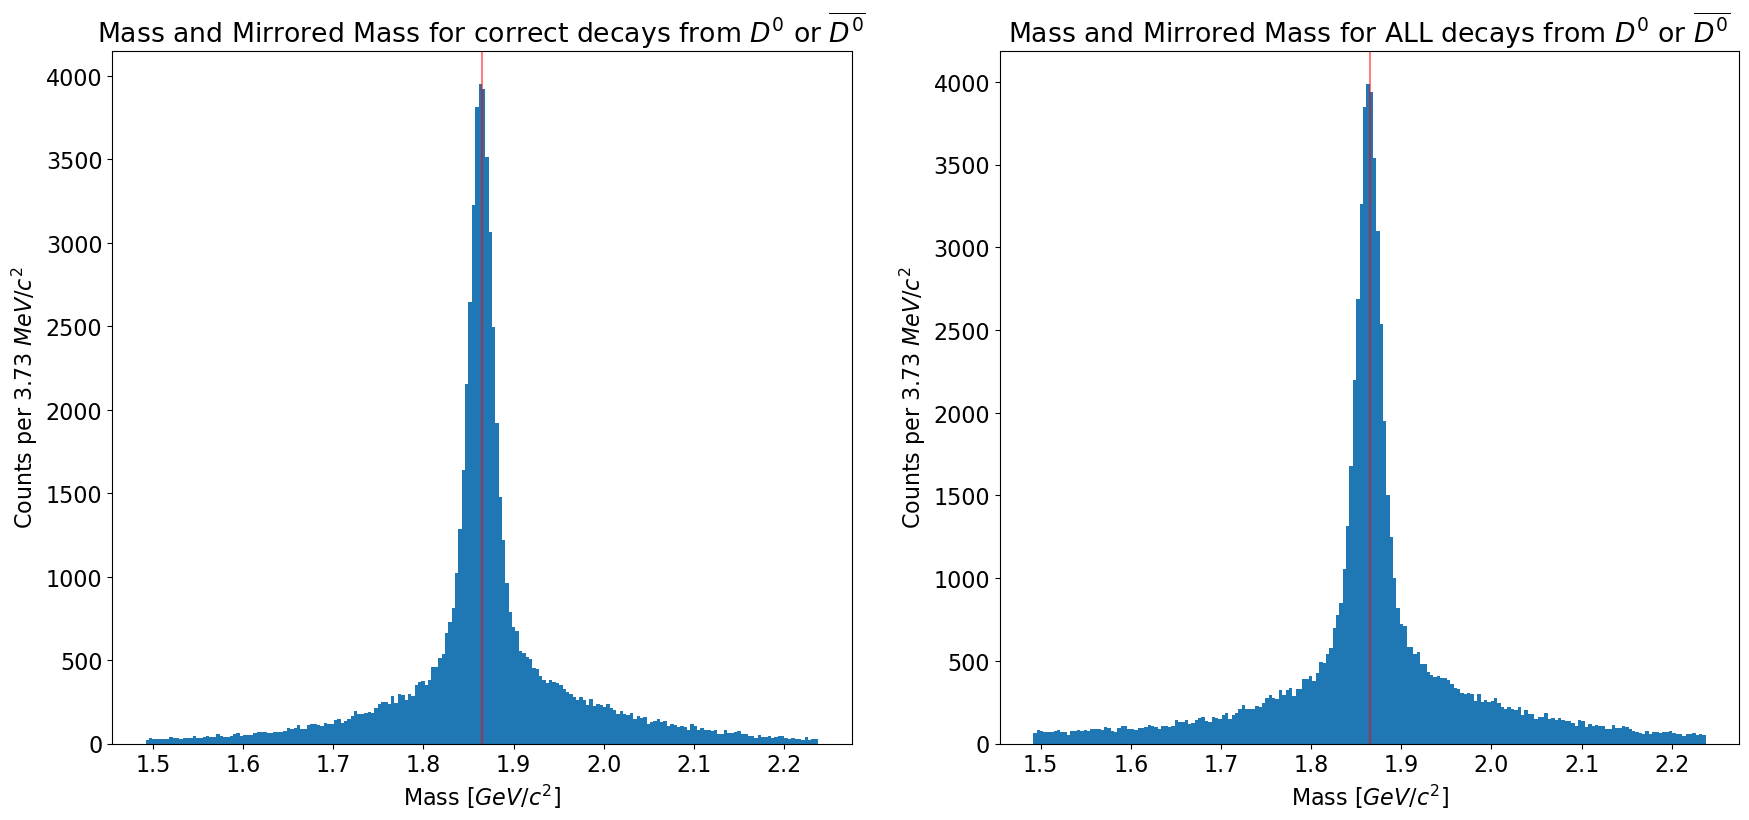

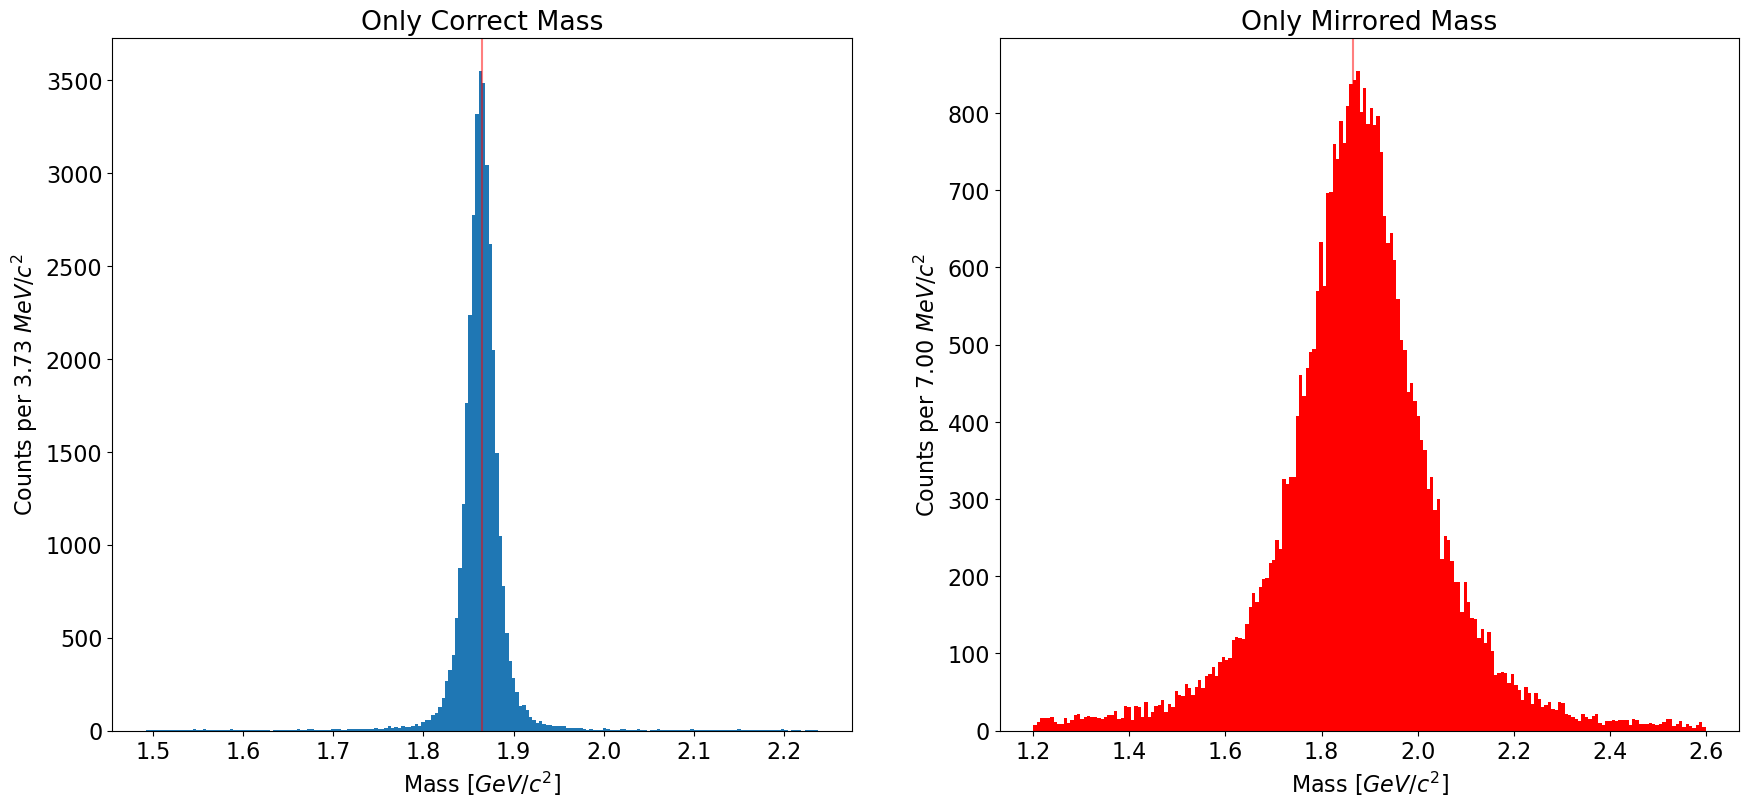

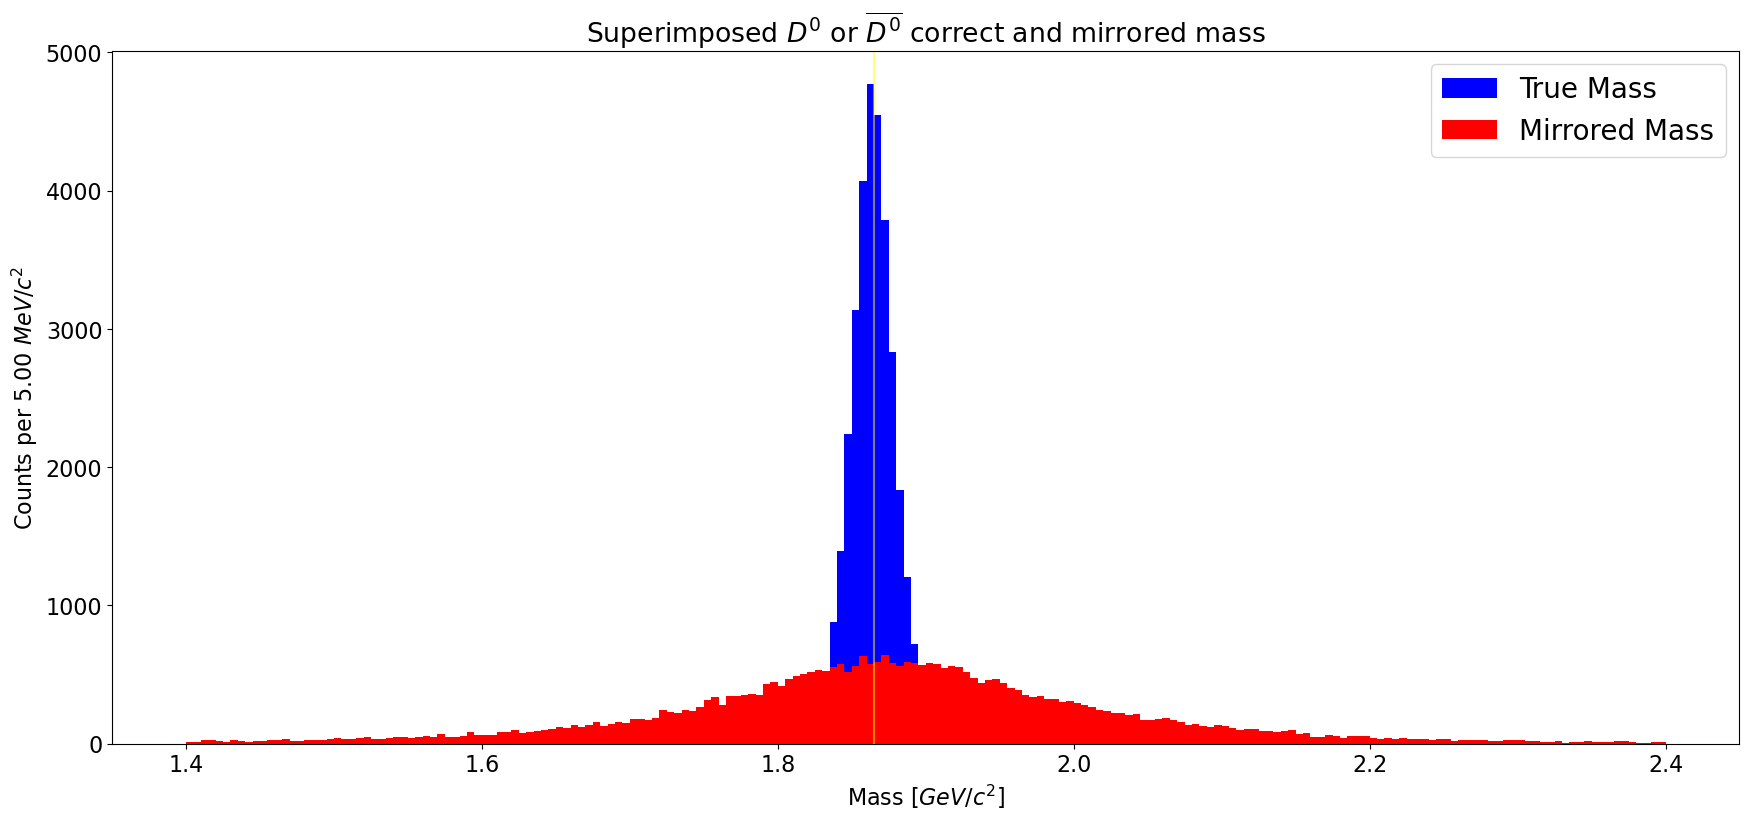

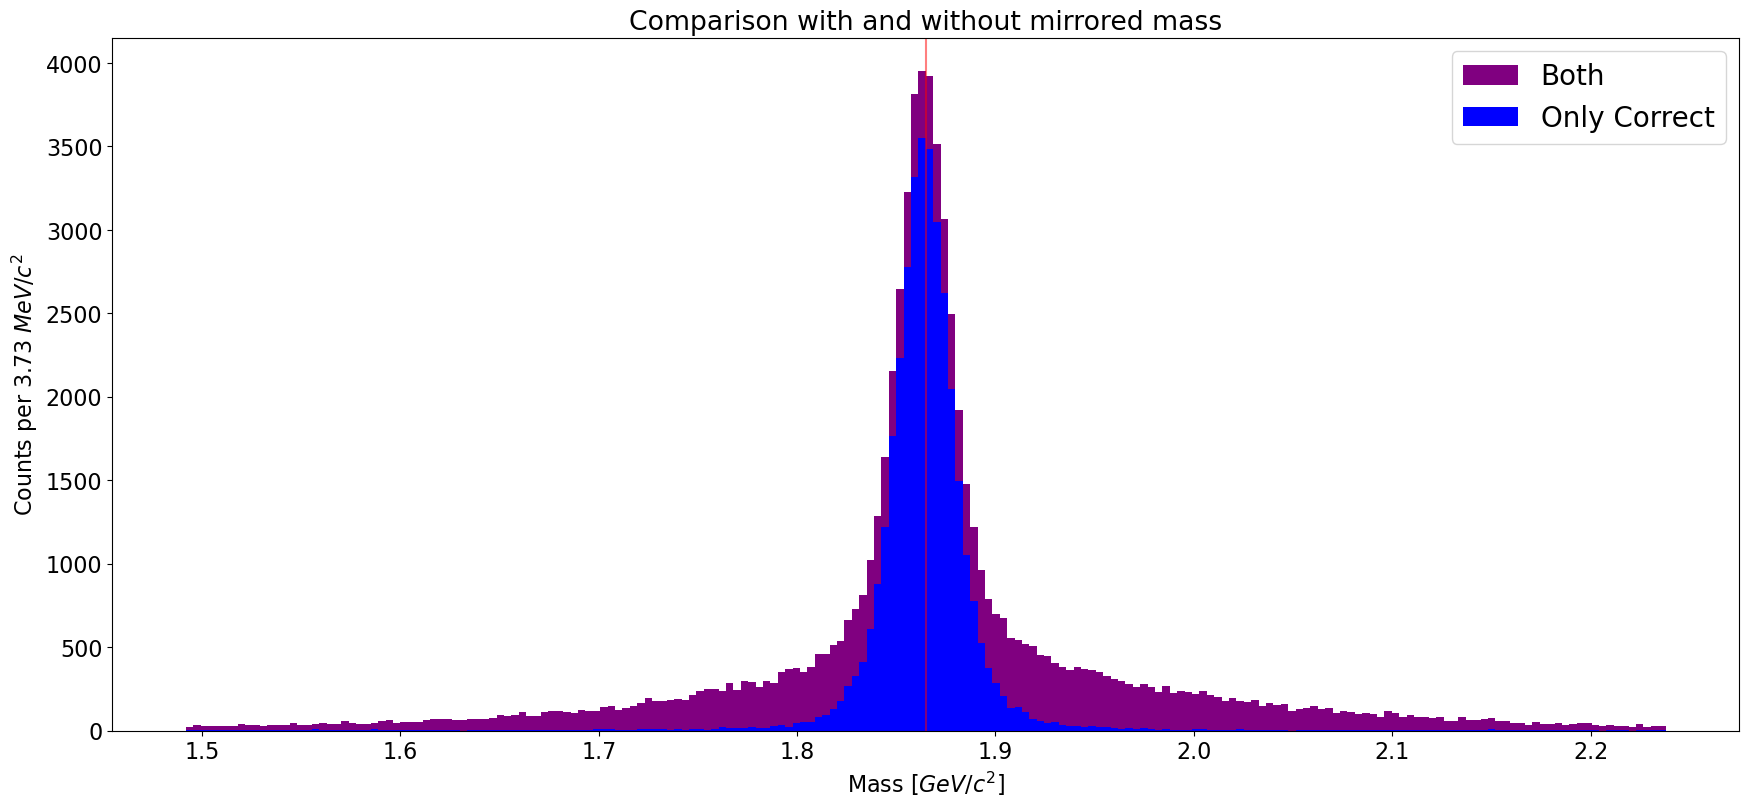

In [4]:

MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
N_BINS = 200
fig, ax = plt.subplots(1,2, figsize=(21,9))
ax[0].hist(np.concatenate([df["inv_mass"], df["mirror_mass"]]), range=(MIN_MASS, MAX_MASS), bins=N_BINS)
ax[0].set_xlabel(r"Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_title(r"Mass and Mirrored Mass for correct decays from $D^0$ or $\overline{D^0}$")

ax[1].hist(np.concatenate([final_results["inv_mass"], final_results["mirror_mass"]]), range=(MIN_MASS, MAX_MASS), bins=N_BINS)
ax[1].set_xlabel(r"Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_title(r"Mass and Mirrored Mass for ALL decays from $D^0$ or $\overline{D^0}$")

plt.show()

fig, ax = plt.subplots(1,2, figsize=(21,9))
ax[0].hist(df["inv_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS)
ax[0].set_xlabel(r"Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_title(r"Only Correct Mass")

MIN_MASS, MAX_MASS = 1.2, 2.6
ax[1].hist(df["mirror_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="red")
ax[1].set_xlabel(r"Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_title(r"Only Mirrored Mass")
plt.show()

MIN_MASS, MAX_MASS = 1.4, 2.4
fig, ax = plt.subplots(figsize=(21,9))
ax.hist(df["inv_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="blue", label="True Mass")
ax.hist(df["mirror_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="red", label="Mirrored Mass")
ax.set_xlabel(r"Mass $[GeV/c^2]$")
ax.set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax.set_title(r"Superimposed $D^0$ or $\overline{D^0}$ correct and mirrored mass")
ax.axvline(x=m_d0, color="yellow", alpha=0.5)
ax.legend(fontsize=20)
plt.show()

MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
N_BINS = 200
fig, ax = plt.subplots(figsize=(21,9))
ax.hist(np.concatenate([df["inv_mass"], df["mirror_mass"]]), range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="purple", label="Both")
ax.hist(df["inv_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="blue", label="Only Correct")
ax.set_xlabel(r"Mass $[GeV/c^2]$")
ax.set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax.axvline(x=m_d0, color="red", alpha=0.5)
ax.legend(fontsize=20)
ax.set_title(r"Comparison with and without mirrored mass")
plt.show()

# Signal and Mirror Fit

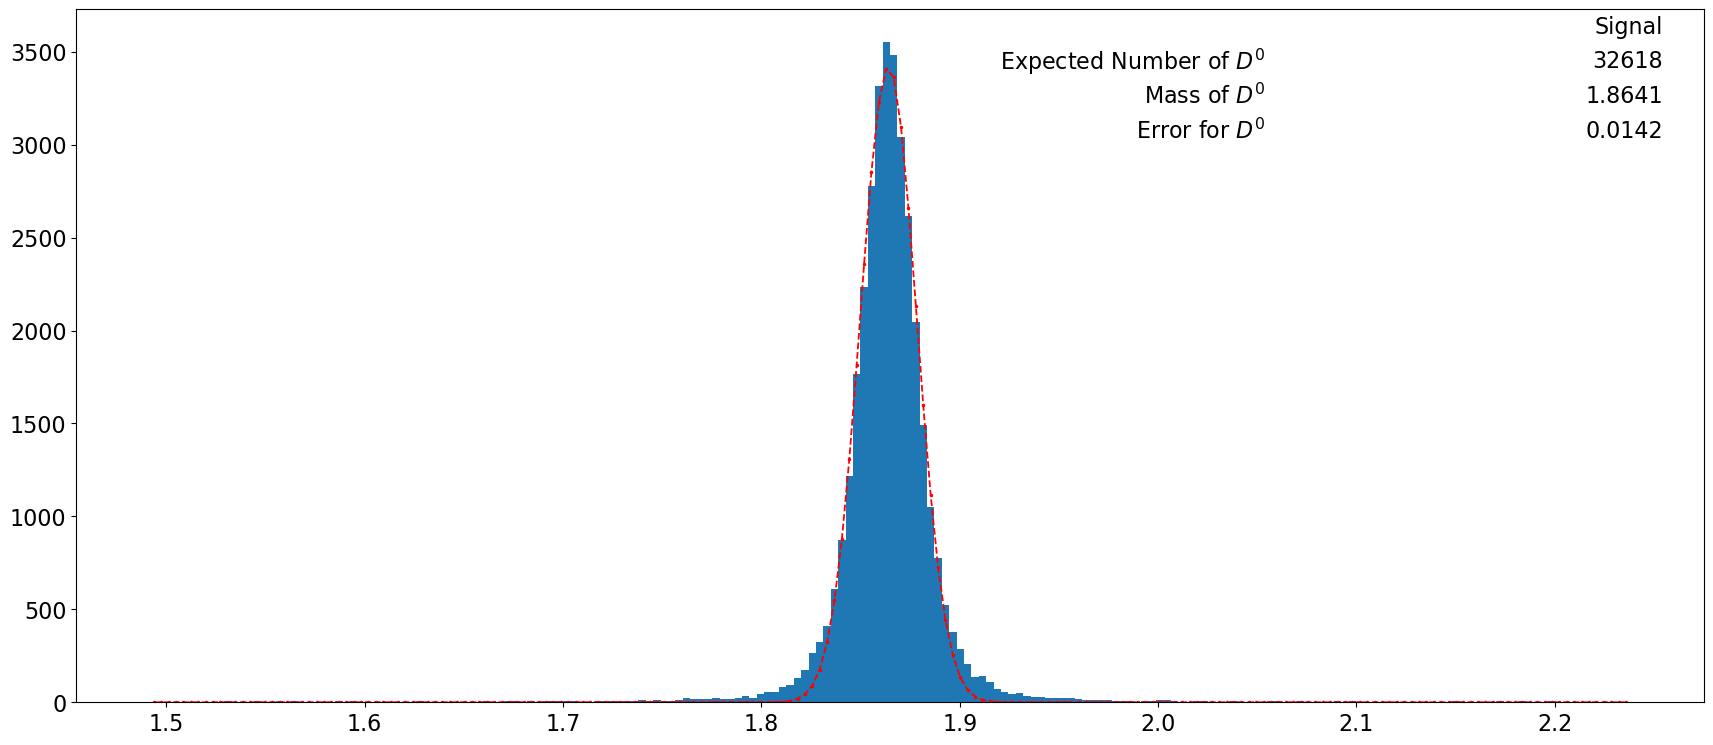

In [5]:
def my_Gauss (x, N, mu, sigma):
    return ( N*norm.pdf(x, loc=mu, scale=sigma) )

MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
approx_particles = sum(df["inv_mass"].between(MIN_MASS,MAX_MASS))

fig, ax = plt.subplots(figsize=(21,9))
sig_counts, sig_edges, _  = ax.hist(df["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
sig_centers = ( sig_edges[:-1] + sig_edges[1:] ) / 2.
signal_fit_res = curve_fit( f = my_Gauss, xdata=sig_centers, ydata=sig_counts, 
                            sigma = np.clip(np.sqrt(sig_centers),a_min=1, a_max=1e+09),
                            p0 = [4000, m_d0, 0.1/6]    )
signal_params = signal_fit_res[0]
ax.plot( sig_centers, my_Gauss( sig_centers, signal_params[0], signal_params[1], signal_params[2] ),
        color='red', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Fitted Signal' )
w3sigma = 0.997300
counts_from_fit = signal_params[0]*w3sigma/binsize
mass_from_fit = signal_params[1]
sigma_from_fit = signal_params[2]

ax.table(
    cellText = [ [f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"] ],
    rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
    colLabels = [ 'Signal' ],
    colLoc = "right",
    bbox = [ 0.75, 0.8, 0.25, 0.2 ],
    edges = 'open',
    rowLoc = 'right'
    )

plt.show()

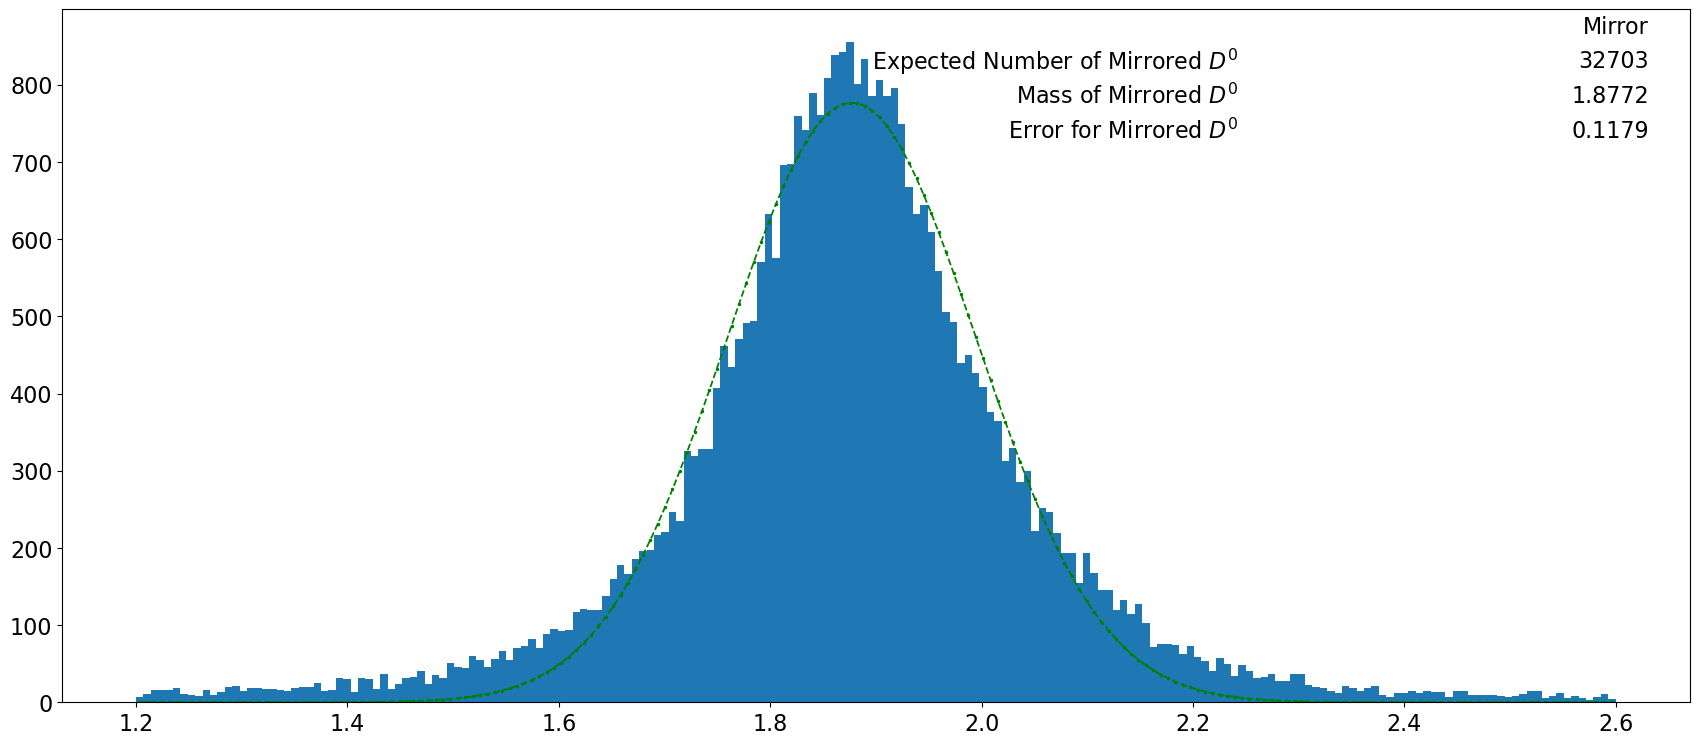

In [6]:
MIN_MASS, MAX_MASS = 1.2, 2.6
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
approx_particles = sum(df["mirror_mass"].between(MIN_MASS,MAX_MASS))

fig, ax = plt.subplots(figsize=(21,9))
mirr_counts, mirr_edges, _  = ax.hist(df["mirror_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
mirr_centers = ( mirr_edges[:-1] + mirr_edges[1:] ) / 2.
mirror_fit_res = curve_fit( f = my_Gauss, xdata=mirr_centers, ydata=mirr_counts, 
                            sigma = np.clip(np.sqrt(mirr_centers),a_min=1, a_max=1e+09),
                            p0 = [800, m_d0, 1.0/6]    )
mirror_params = mirror_fit_res[0]
ax.plot( mirr_centers, my_Gauss( mirr_centers, mirror_params[0], mirror_params[1], mirror_params[2] ),
        color='green', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Mirror component' )
w3sigma = 0.997300
counts_from_fit = mirror_params[0]*w3sigma/binsize
mass_from_fit = mirror_params[1]
sigma_from_fit = mirror_params[2]

ax.table(
    cellText = [ [f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"] ],
    rowLabels = [ r'Expected Number of Mirrored $D^0$', r'Mass of Mirrored $D^0$', r'Error for Mirrored $D^0$'],
    colLabels = [ 'Mirror' ],
    colLoc = "right",
    bbox = [ 0.75, 0.8, 0.25, 0.2 ],
    edges = 'open',
    rowLoc = 'right'
    )

plt.show()

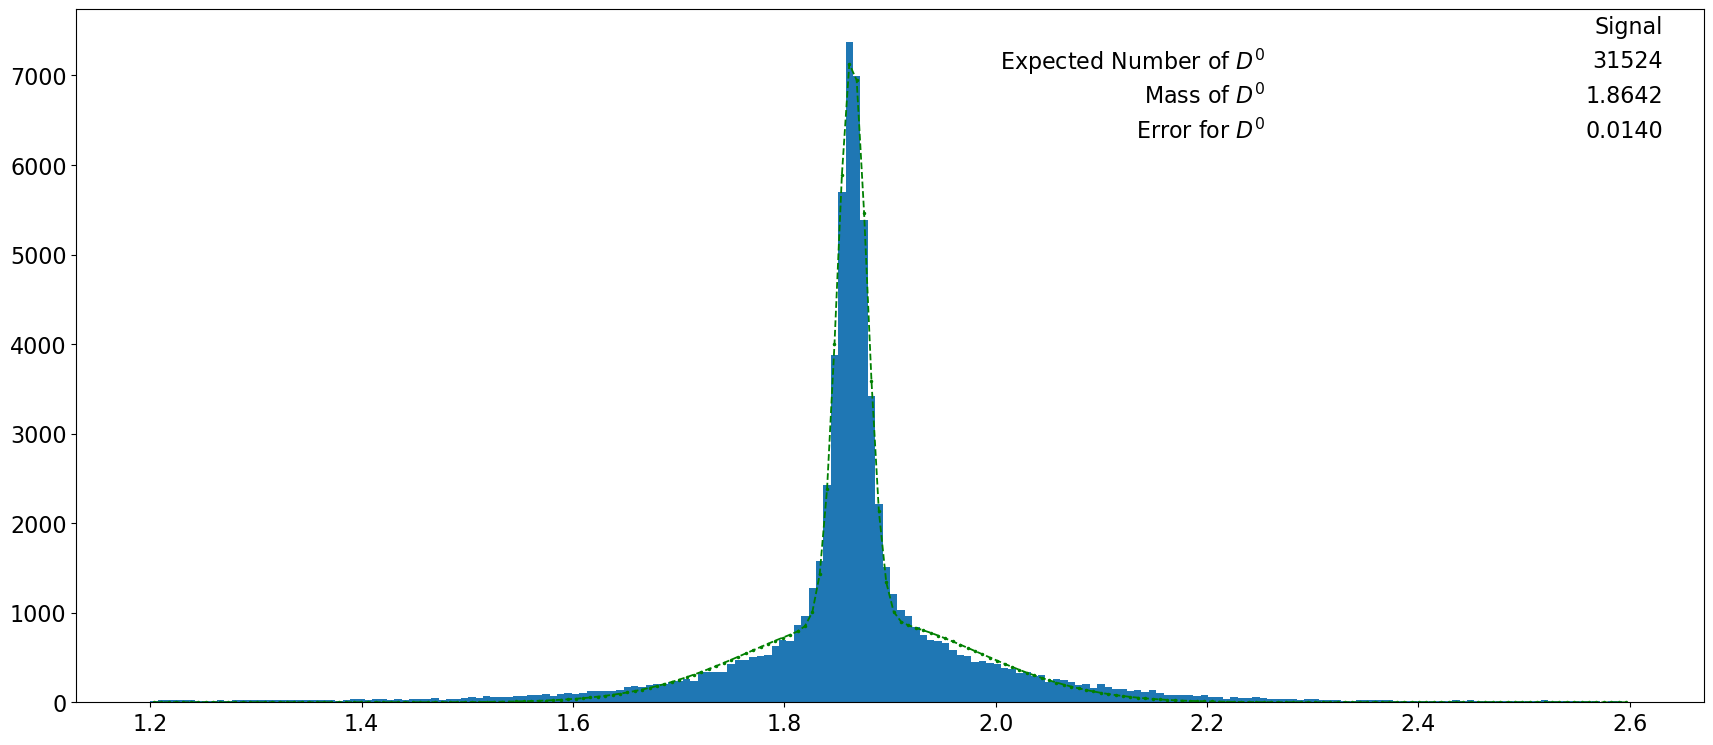

In [7]:
def both(x, N1, mu1, sigma1, N2, mu2, sigma2):
    return ( N1*norm.pdf(x, loc=mu1, scale=sigma1) + N2*norm.pdf(x, loc=mu2, scale=sigma2)  )

MIN_MASS, MAX_MASS = 1.2, 2.6
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS

fig, ax = plt.subplots(figsize=(21,9))
both_counts, both_edges, _  = ax.hist(np.concatenate([df["inv_mass"], df["mirror_mass"]]), bins=N_BINS, range=(MIN_MASS, MAX_MASS))
both_centers = ( both_edges[:-1] + both_edges[1:] ) / 2.
both_fit_res = curve_fit( f = both, xdata=both_centers, ydata=both_counts, 
                            sigma = np.clip(np.sqrt(both_centers),a_min=1, a_max=1e+09),
                            p0 = [signal_params[0], signal_params[1], signal_params[2],
                                  mirror_params[0], mirror_params[1], mirror_params[2] ]  )
both_params = both_fit_res[0]
ax.plot( both_centers, both( both_centers, both_params[0], both_params[1], both_params[2], both_params[3], both_params[4], \
                                           both_params[5]),color='green', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

w3sigma = 0.997300
counts_from_fit = both_params[0]*w3sigma/binsize
mass_from_fit = both_params[1]
sigma_from_fit = both_params[2]

ax.table(
    cellText = [ [f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"] ],
    rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
    colLabels = [ 'Signal' ],
    colLoc = "right",
    bbox = [ 0.75, 0.8, 0.25, 0.2 ],
    edges = 'open',
    rowLoc = 'right'
    )
plt.show()

In [8]:
print(f"N1: {both_params[0]} \nN2: {both_params[3]}")
print(f"N2/N1: {both_params[3]/both_params[0]:.3f}")
rif = sum( df[df["mirror_mass"].between(m_d0-3*both_params[2], m_d0+3*both_params[2])]["mirror_mass"] )
sig = sum( df[df["inv_mass"].between(m_d0-3*both_params[2], m_d0+3*both_params[2])]["inv_mass"] )
print(f"Counts from bin-sum in 3sigma interval for Signal: {sig:.3f}")
print(f"Counts from bin-sum in 3sigma interval for Mirror: {rif:.3f}")
print(f"Counts Riflesso/Signale: {rif/sig:.3f}")

N1: 221.2651327050876 
N2: 250.52505278155144
N2/N1: 1.132
Counts from bin-sum in 3sigma interval for Signal: 62124.194
Counts from bin-sum in 3sigma interval for Mirror: 17898.553
Counts Riflesso/Signale: 0.288


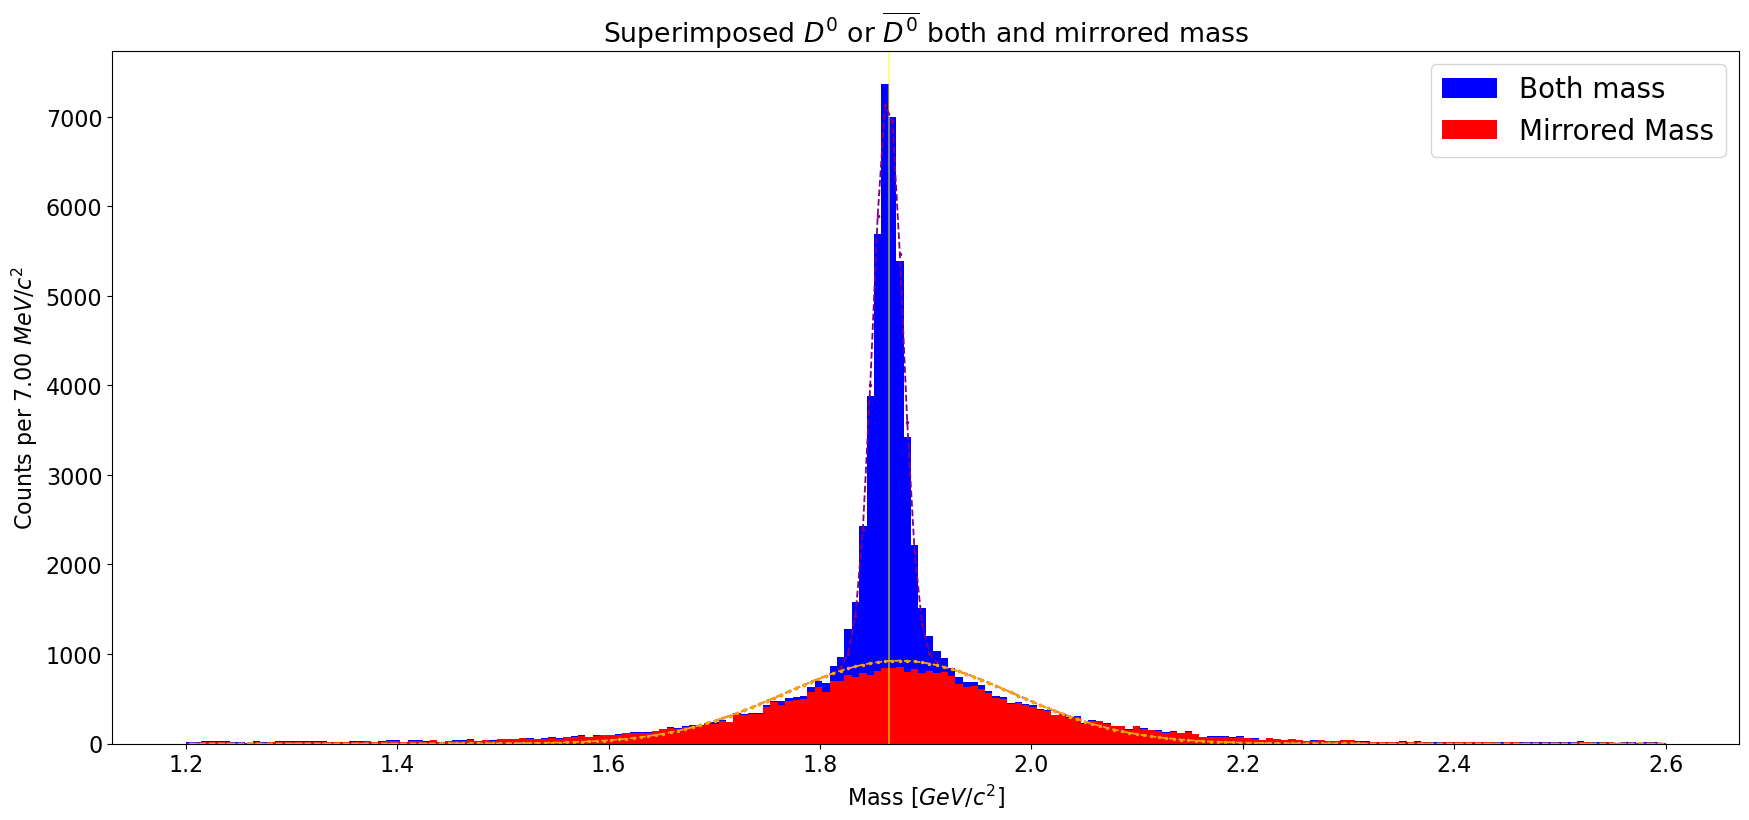

array([2.21265133e+02, 1.86415320e+00, 1.39608195e-02, 2.50525053e+02,
       1.87452562e+00, 1.08072984e-01])

In [9]:
MIN_MASS, MAX_MASS = 1.2, 2.6
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
fig, ax = plt.subplots(figsize=(21,9))
ax.hist(np.concatenate([df["inv_mass"], df["mirror_mass"]]), range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="blue", label="Both mass")
ax.hist(df["mirror_mass"], range=(MIN_MASS, MAX_MASS), bins=N_BINS, color="red", label="Mirrored Mass")
ax.set_xlabel(r"Mass $[GeV/c^2]$")
ax.set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax.set_title(r"Superimposed $D^0$ or $\overline{D^0}$ both and mirrored mass")
ax.axvline(x=m_d0, color="yellow", alpha=0.5)
ax.legend(fontsize=20)

ax.plot( both_centers, both( both_centers, both_params[0], both_params[1], both_params[2], both_params[3], both_params[4], \
                                           both_params[5]),color='purple', marker='o', linestyle='dashed', \
                        linewidth=1.3, markersize=1.5, label = 'Both')

ax.plot( mirr_centers, my_Gauss( mirr_centers, both_params[3], both_params[4], both_params[5] ),
        color='orange', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Mirror component' )
plt.show()
both_params

# Variables to cut on study

In [10]:
pt_slice = [ [0,1], [1,2], [2,3], [3,5], [5,8], [8,16], [16, 500]  ]

## TOFka - Global

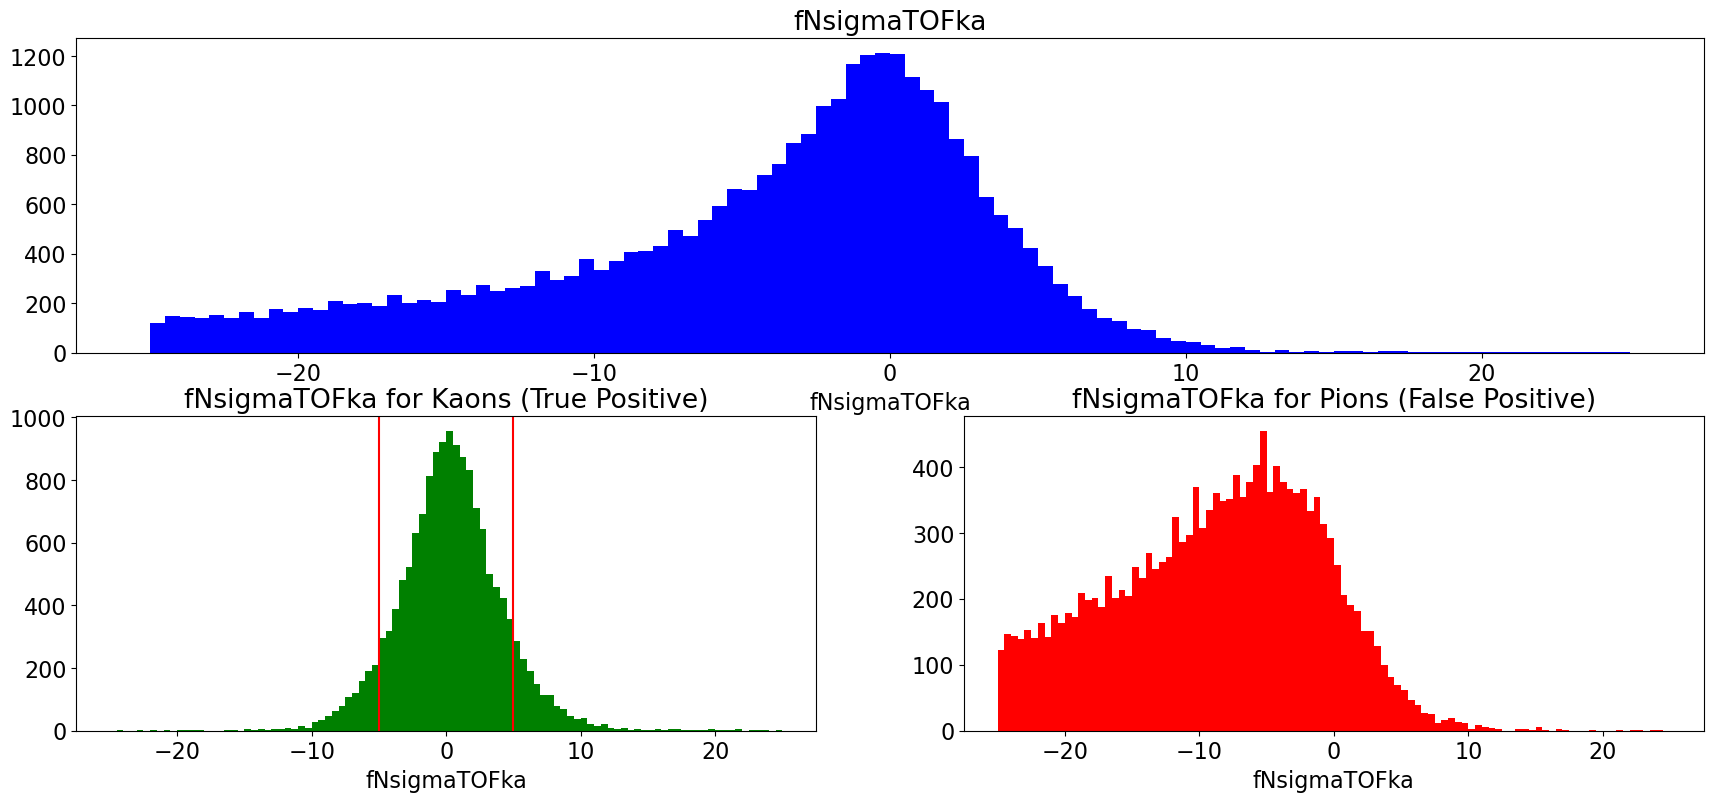

In [11]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([df["TOFka"],df["mirror_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFka")
axes["top"].set_xlabel("fNsigmaTOFka")
axes["top"].set_label("Counts")

axes["left"].hist(df["TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTOFka")
axes["left"].set_label("Counts")
axes["left"].axvline(x=-5, color="red")
axes["left"].axvline(x=+5, color="red")

axes["right"].hist(df["mirror_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTOFka")
axes["right"].set_label("Counts")

plt.show()

## Pt slices

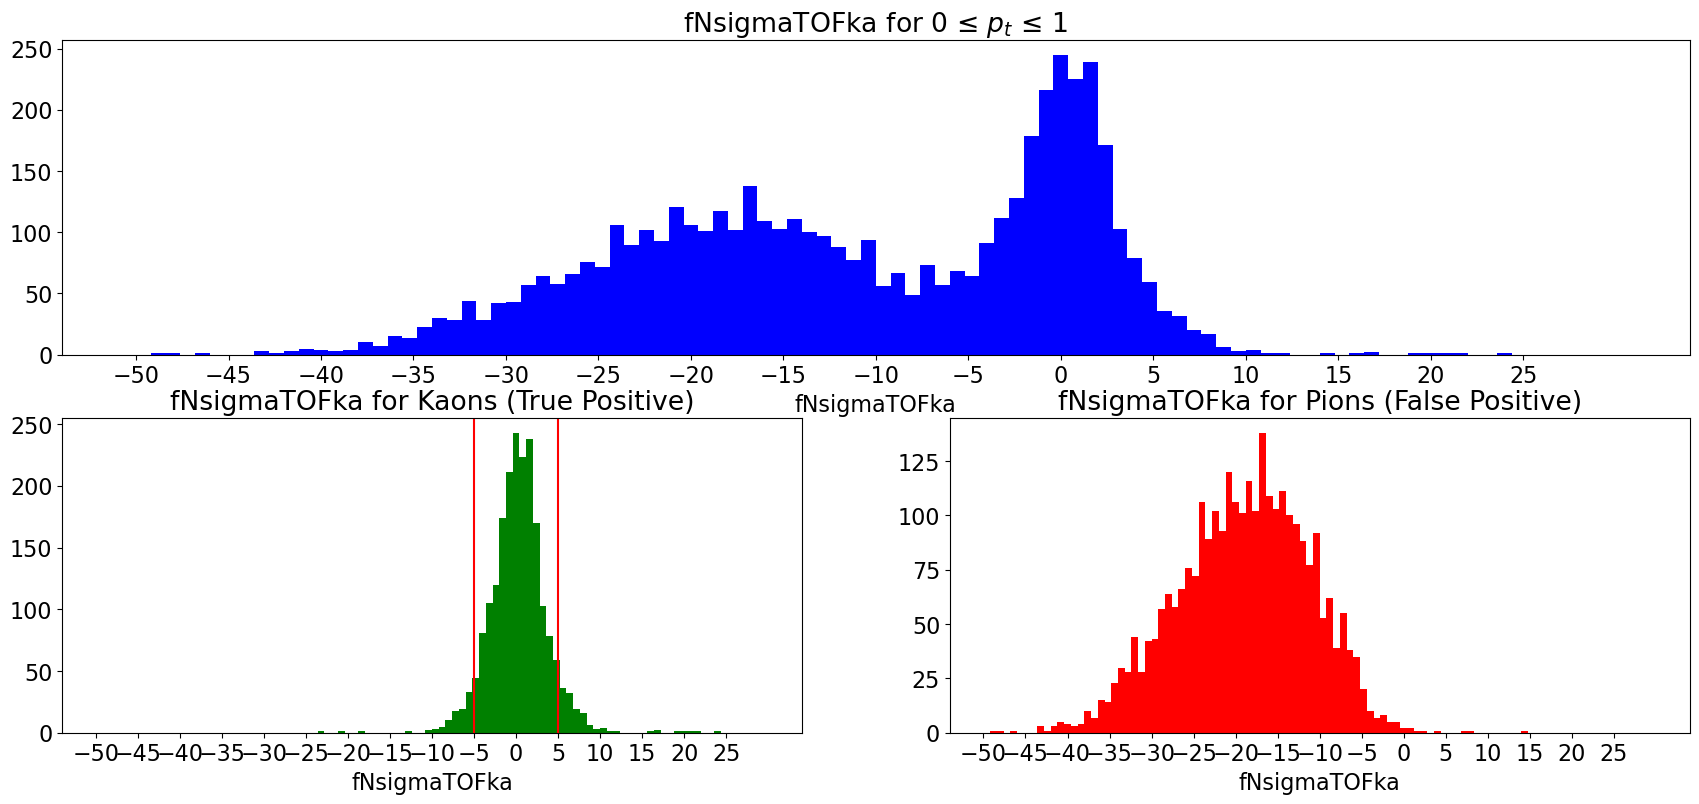

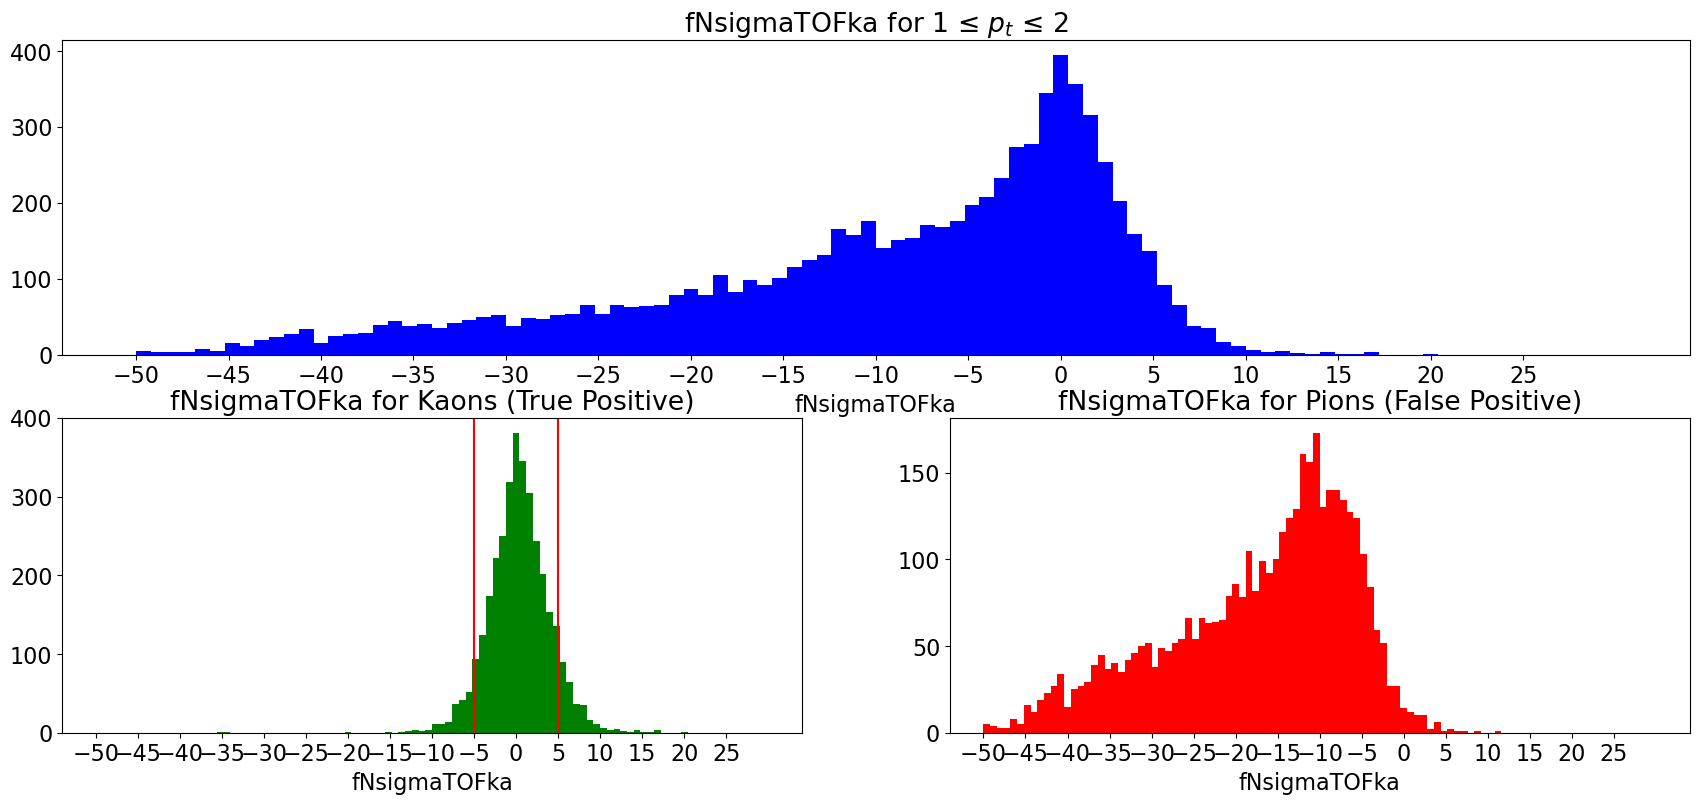

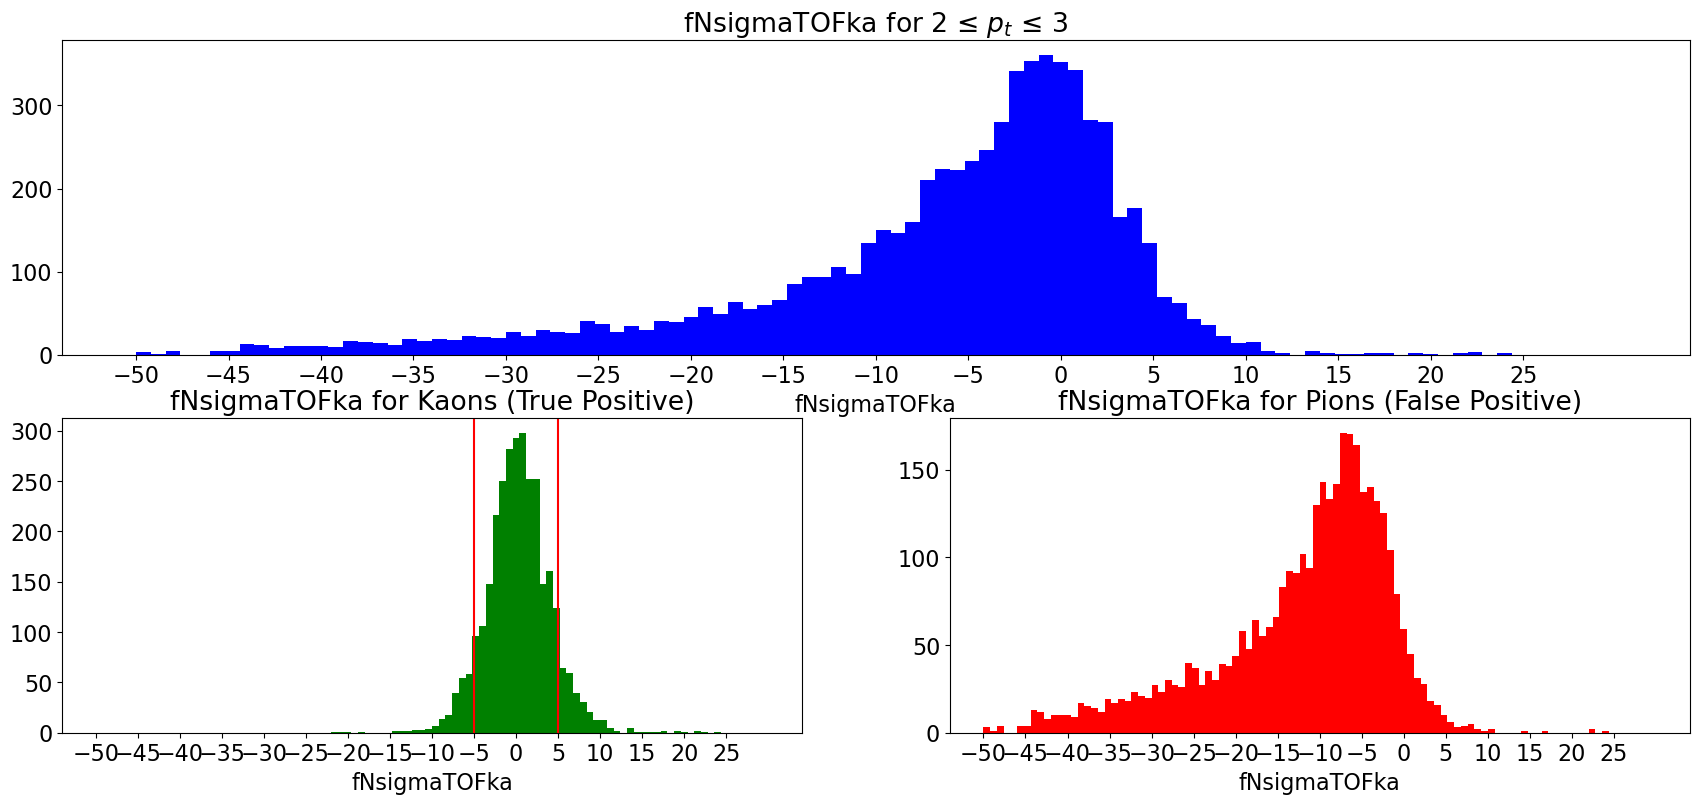

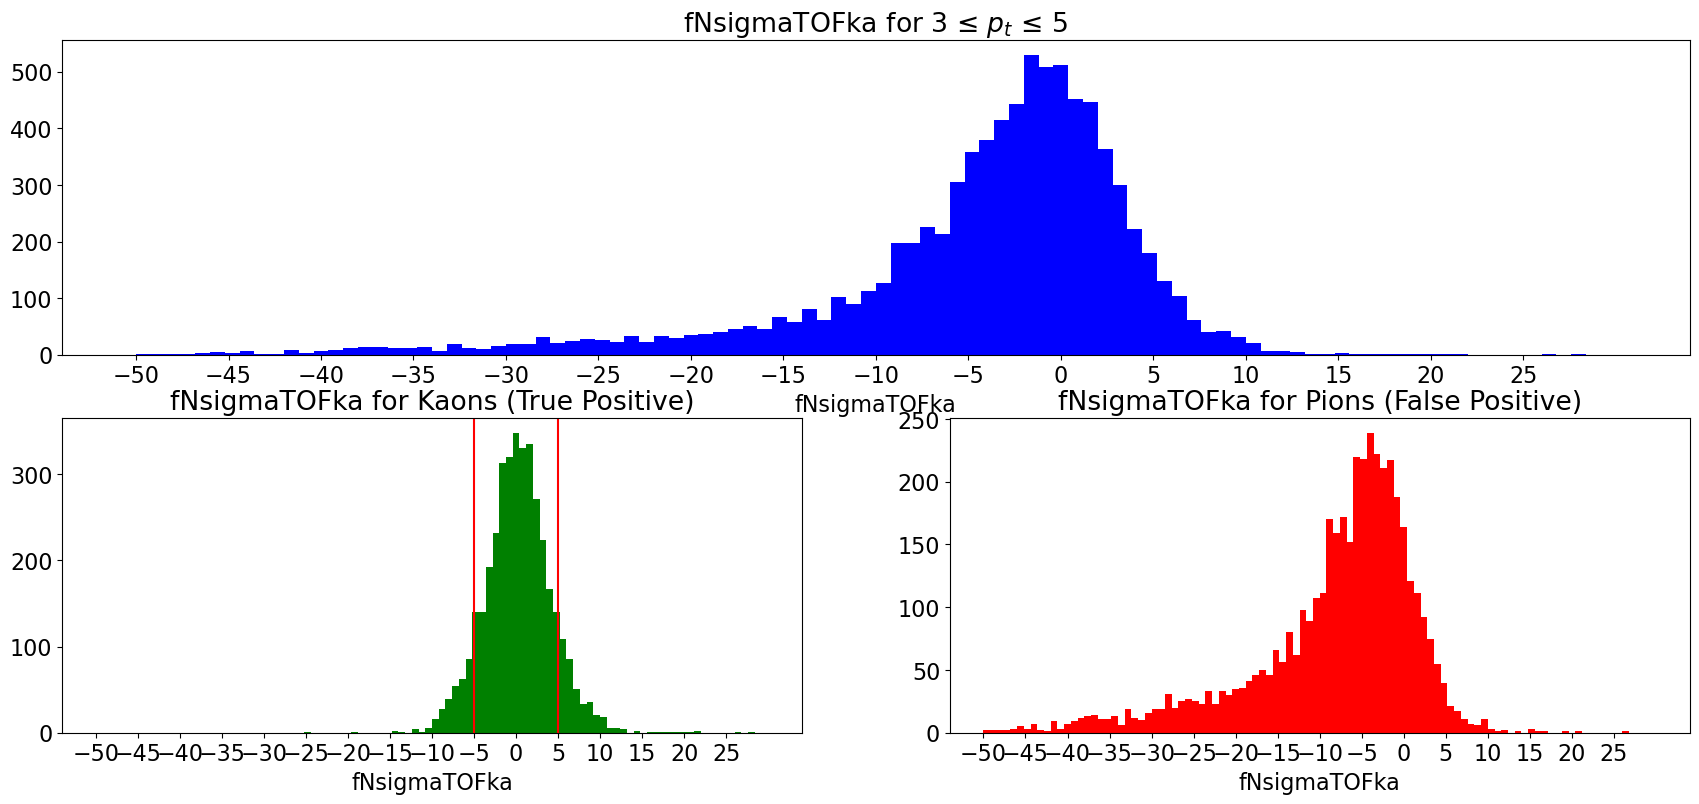

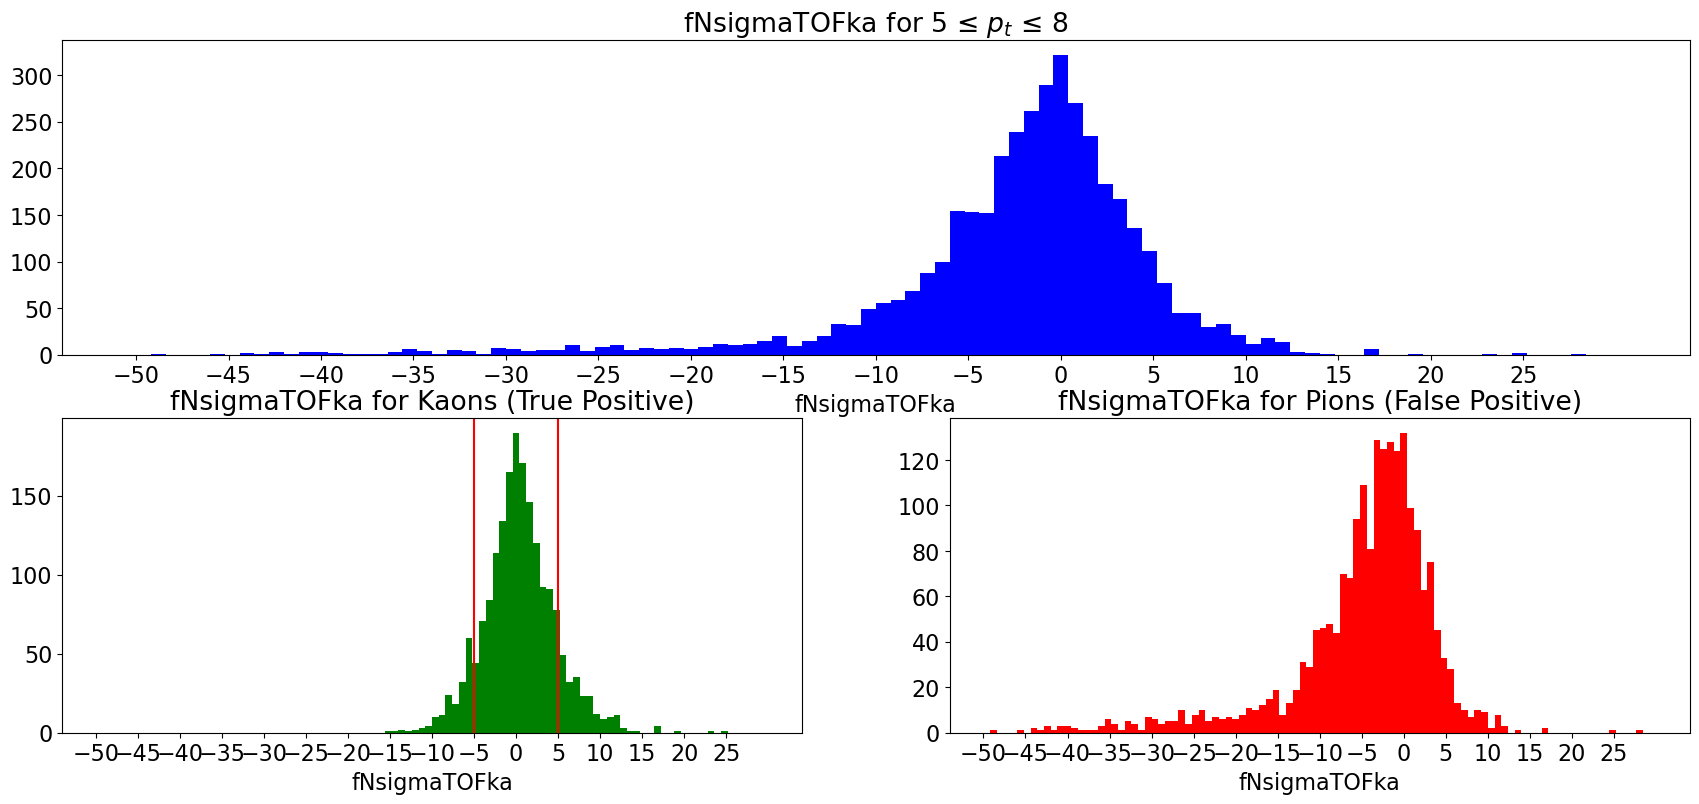

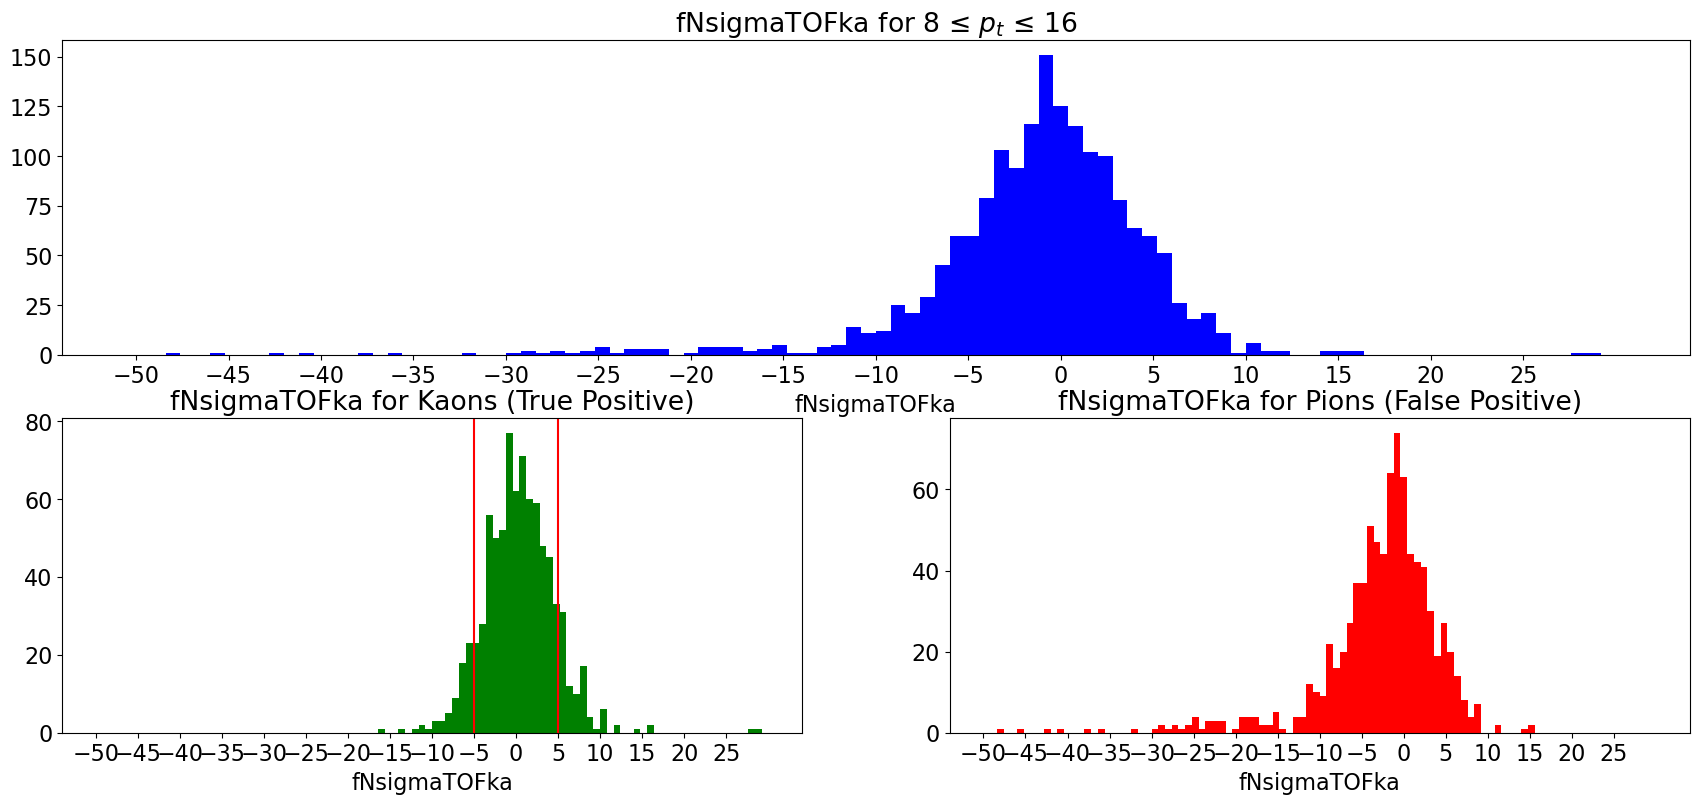

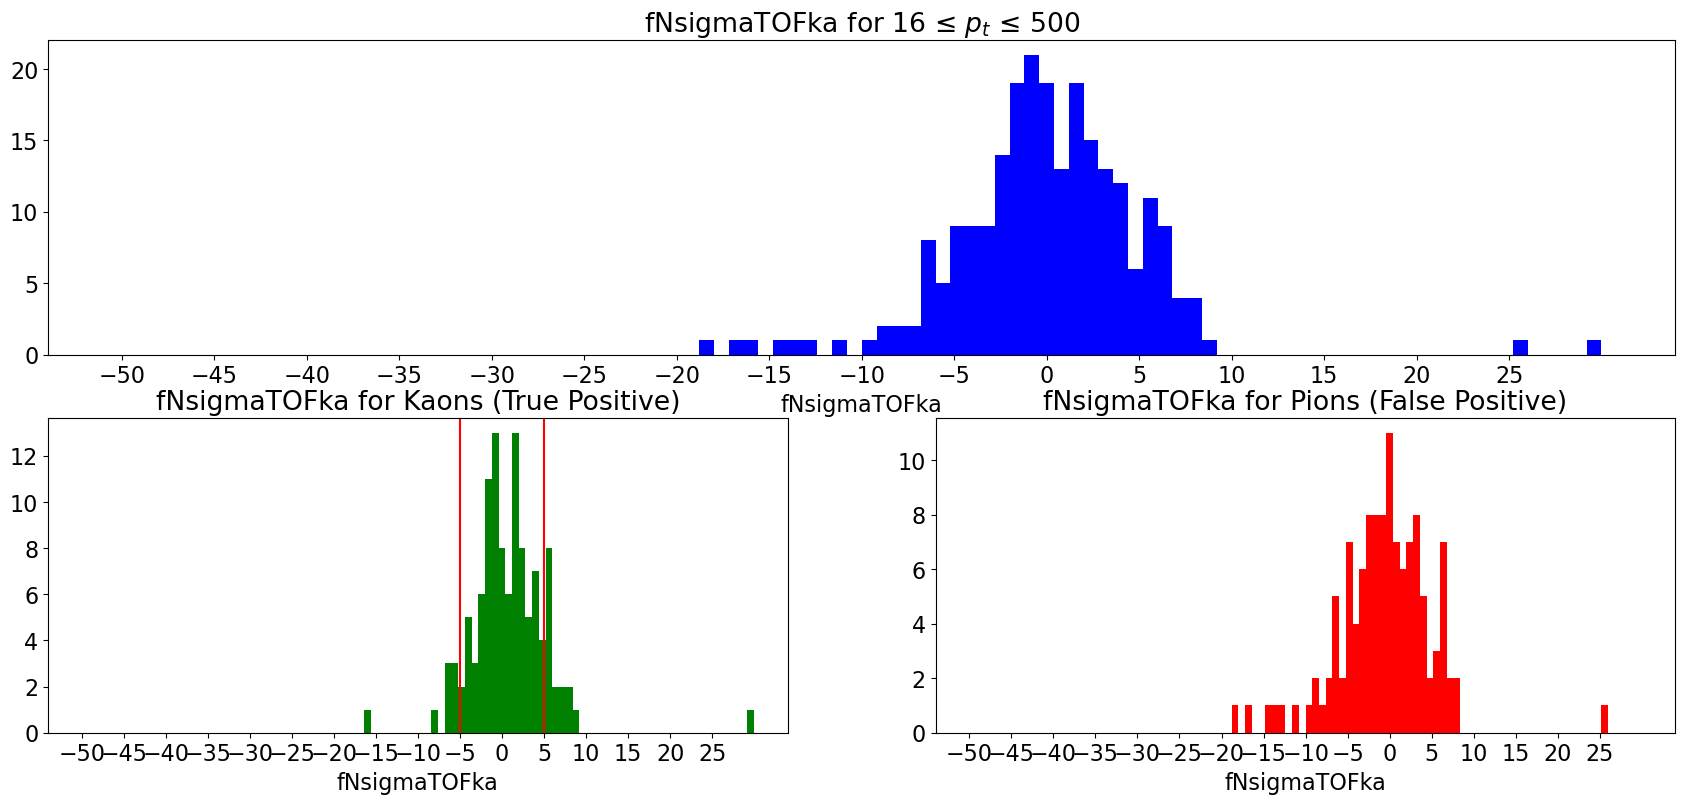

In [61]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

bucket_finite = []
bucket_unavailable = []

bucket_finite.append(sum(df["TOFka"]!= -999) )
bucket_unavailable.append(sum(df["TOFka"]== -999) )

for i in range (len(pt_slice)):
    pt_lim = pt_slice[i]
    pt_mask = df["pt"].between(pt_lim[0], pt_lim[1])

    fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
    N_BINS = 100
    MIN_TOF, MAX_TOF = -50, 30
    axes["top"].hist(np.concat([df[pt_mask]["TOFka"],df[pt_mask]["mirror_TOFka"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
    axes["top"].set_title(f"fNsigmaTOFka for {pt_lim[0]} ≤ $p_t$ ≤ {pt_lim[1]}")
    axes["top"].set_xlabel("fNsigmaTOFka")
    axes["top"].set_xticks(np.arange(MIN_TOF, MAX_TOF, 5))
    axes["top"].set_label("Counts")
    
    axes["left"].hist(df[pt_mask]["TOFka"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
    axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")
    axes["left"].set_xlabel("fNsigmaTOFka")
    axes["left"].set_xticks(np.arange(MIN_TOF, MAX_TOF, 5))
    axes["left"].set_label("Counts")
    axes["left"].axvline(x=-5, color="red")
    axes["left"].axvline(x=+5, color="red")
    
    axes["right"].hist(df[pt_mask]["mirror_TOFka"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
    axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")
    axes["right"].set_xlabel("fNsigmaTOFka")
    axes["right"].set_xticks(np.arange(MIN_TOF, MAX_TOF, 5))
    axes["right"].set_label("Counts")
    
    plt.show()

    bucket_finite.append( sum(df[pt_mask]["TOFka"]!=-999)/bucket_finite[0]  )
    bucket_unavailable.append( sum(df[pt_mask]["TOFka"]== -999)/bucket_unavailable[0] )

bucket_finite[0] = bucket_finite[0]/len(df)
bucket_unavailable[0] = bucket_unavailable[0]/len(df)

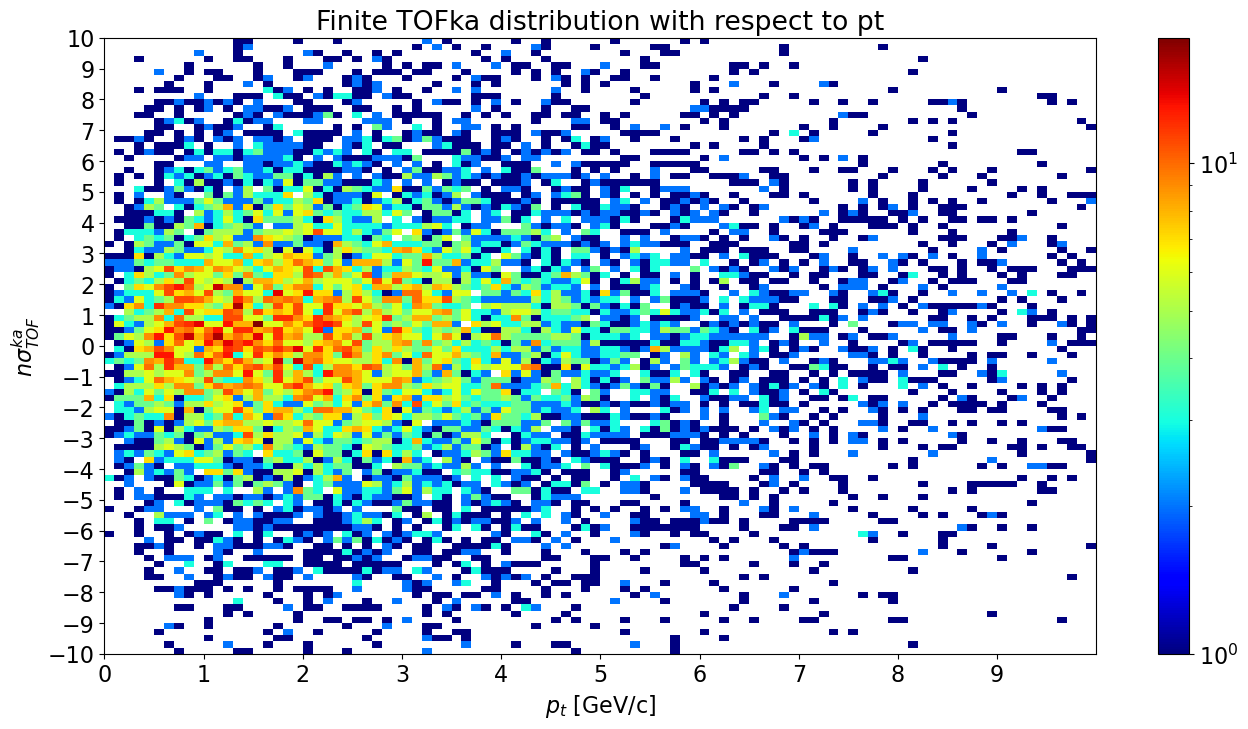

Momentum Distribution with respect to TOFka availability (%)
Overall is respect to all signal entries while the other columns are relative to the Overall value


,Overall,"[0, 1]","[1, 2]","[2, 3]","[3, 5]","[5, 8]","[8, 16]","[16, 500]"
Finite,45.63,13.35,21.7,19.86,25.19,13.05,6.0,0.85
Unavailable,54.37,18.9,26.04,19.64,21.79,9.82,3.43,0.38


In [72]:
min_cut_TOF_KA, max_cut_TOF_KA = -10, 10

fig, ax = plt.subplots(figsize=(16,8))
plt.hist2d(df["pt"], df["TOFka"], (100, 100), cmap="jet", norm=LogNorm(), range=[[0,10], [min_cut_TOF_KA, max_cut_TOF_KA]] )
plt.colorbar()
plt.xlabel(r"$p_t$ [GeV/c]")
plt.ylabel(r"$n\sigma^{ka}_{TOF}$")
plt.xticks(np.arange(0,10,1))
plt.yticks(np.arange(min_cut_TOF_KA, max_cut_TOF_KA+1, 1))
plt.title("Finite TOFka distribution with respect to pt")
plt.show()

TOFka_distribution = pd.DataFrame(columns=["Overall"]+[str(item) for item in pt_slice], index=["Finite", "Unavailable"])
TOFka_distribution.loc["Finite"] = np.array(bucket_finite)*100
TOFka_distribution.loc["Unavailable"] = np.array(bucket_unavailable)*100
pd.set_option("display.precision", 2)
print("Momentum Distribution with respect to TOFka availability (%)\nOverall is respect to all signal entries while the other columns are\
 relative to the Overall value")
TOFka_distribution

## TPCka - Global

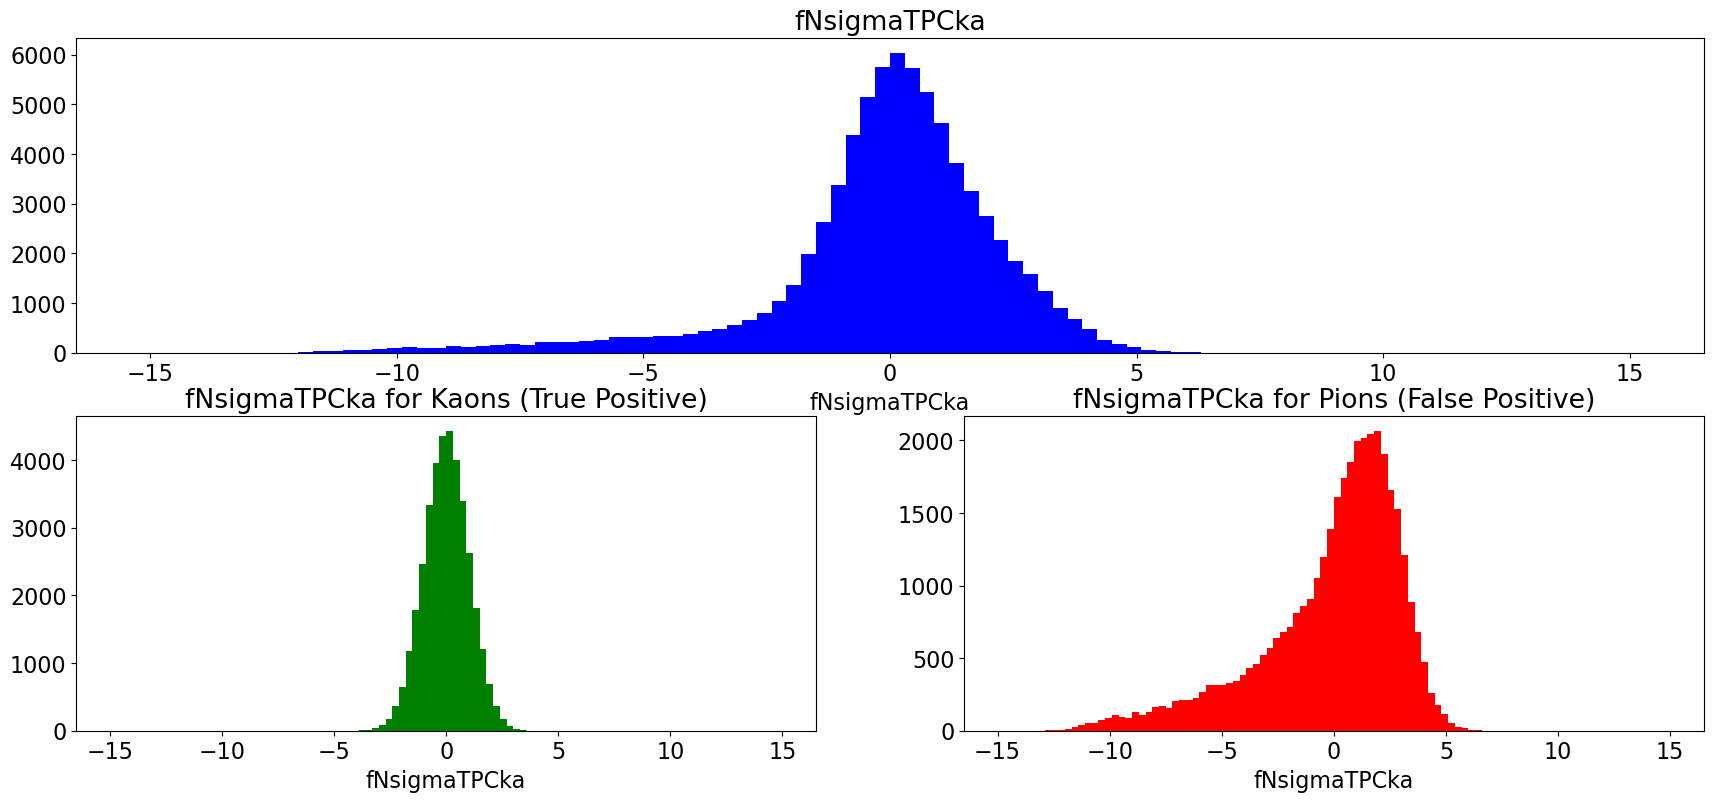

In [73]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([df["TPCka"],df["mirror_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCka")
axes["top"].set_xlabel("fNsigmaTPCka")
axes["top"].set_label("Counts")

axes["left"].hist(df["TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
axes["left"].set_xlabel("fNsigmaTPCka")
axes["left"].set_label("Counts")

axes["right"].hist(df["mirror_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
axes["right"].set_xlabel("fNsigmaTPCka")
axes["right"].set_label("Counts")

plt.show()

## pt slices

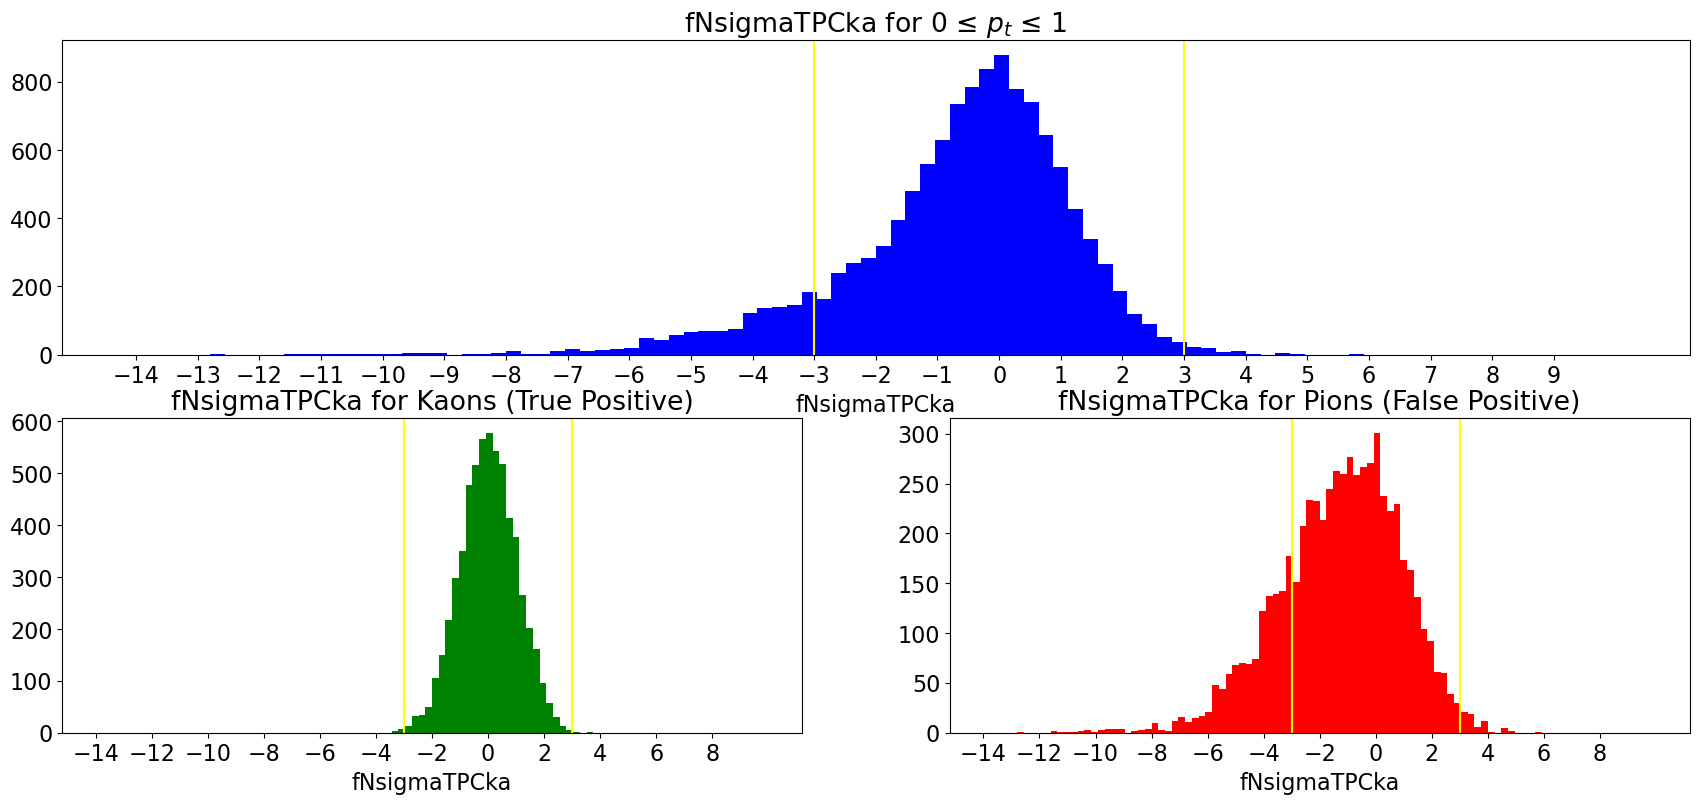

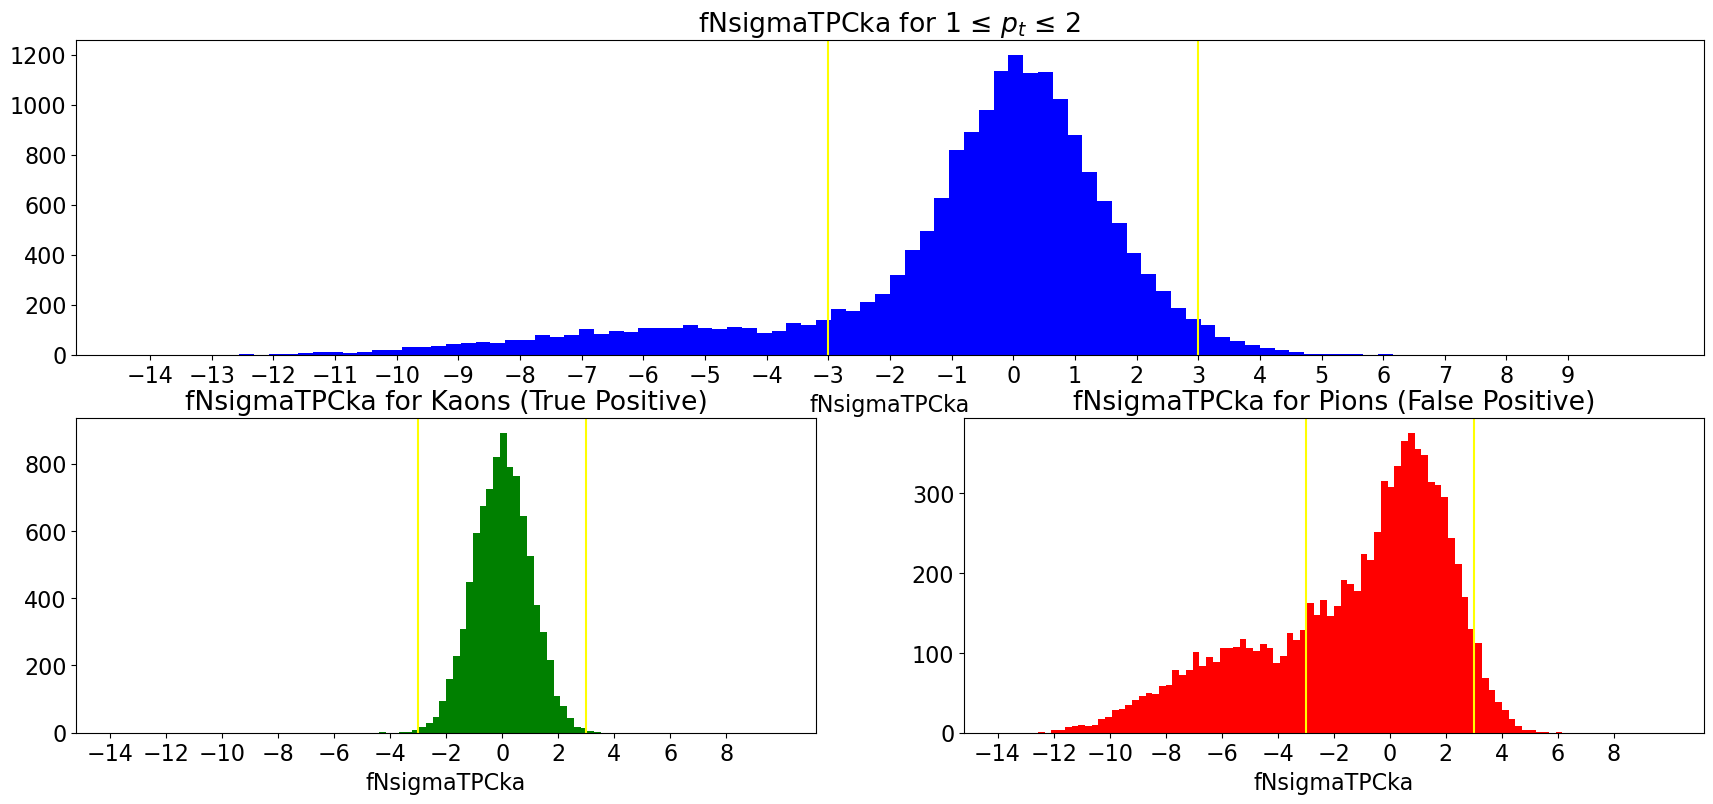

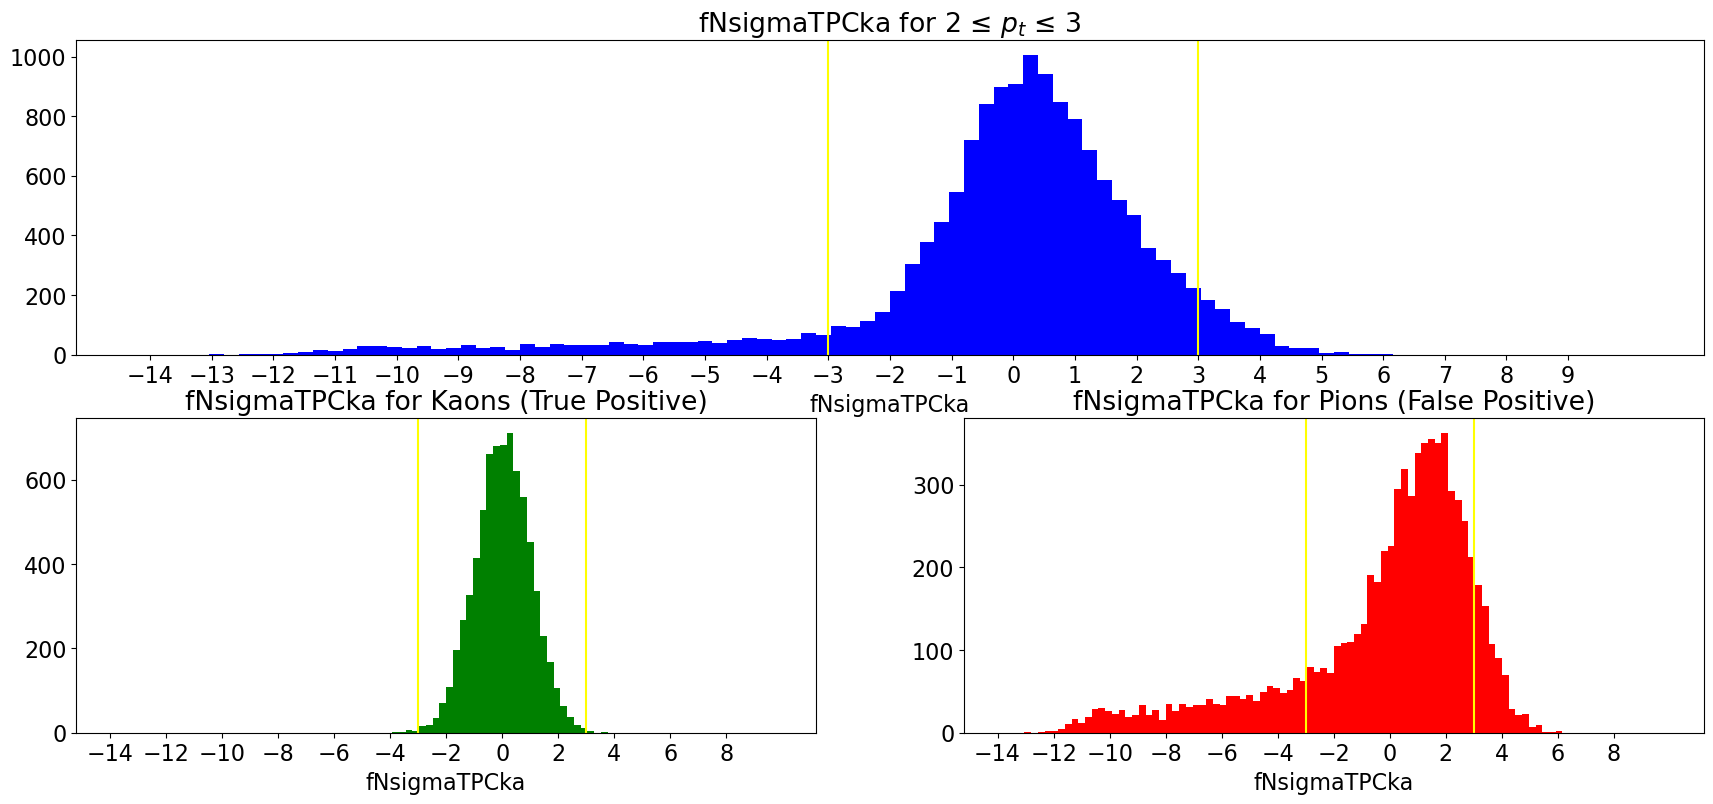

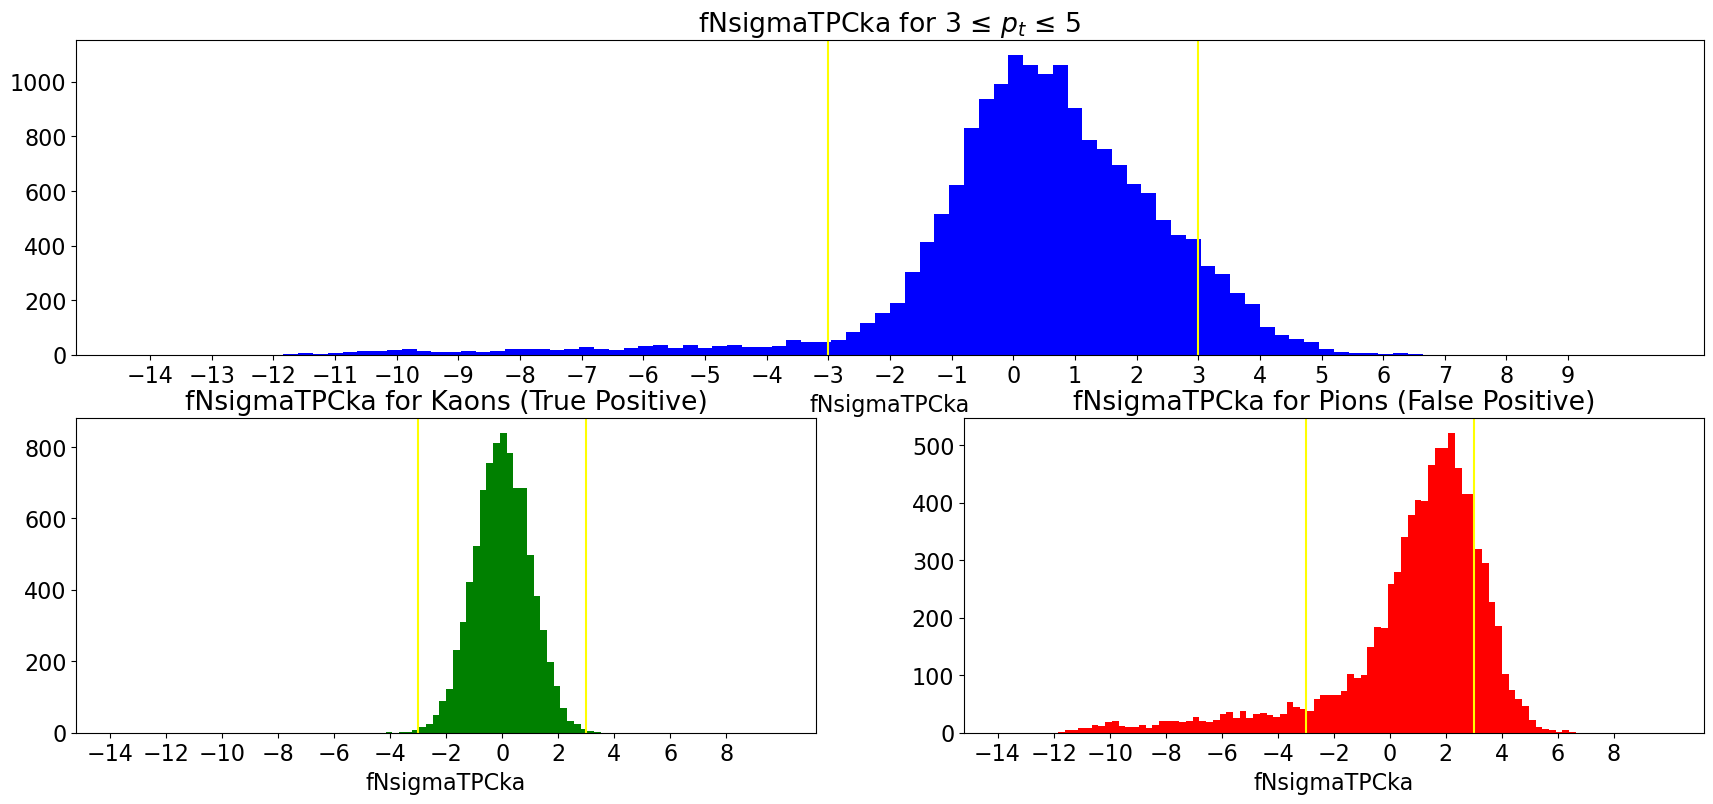

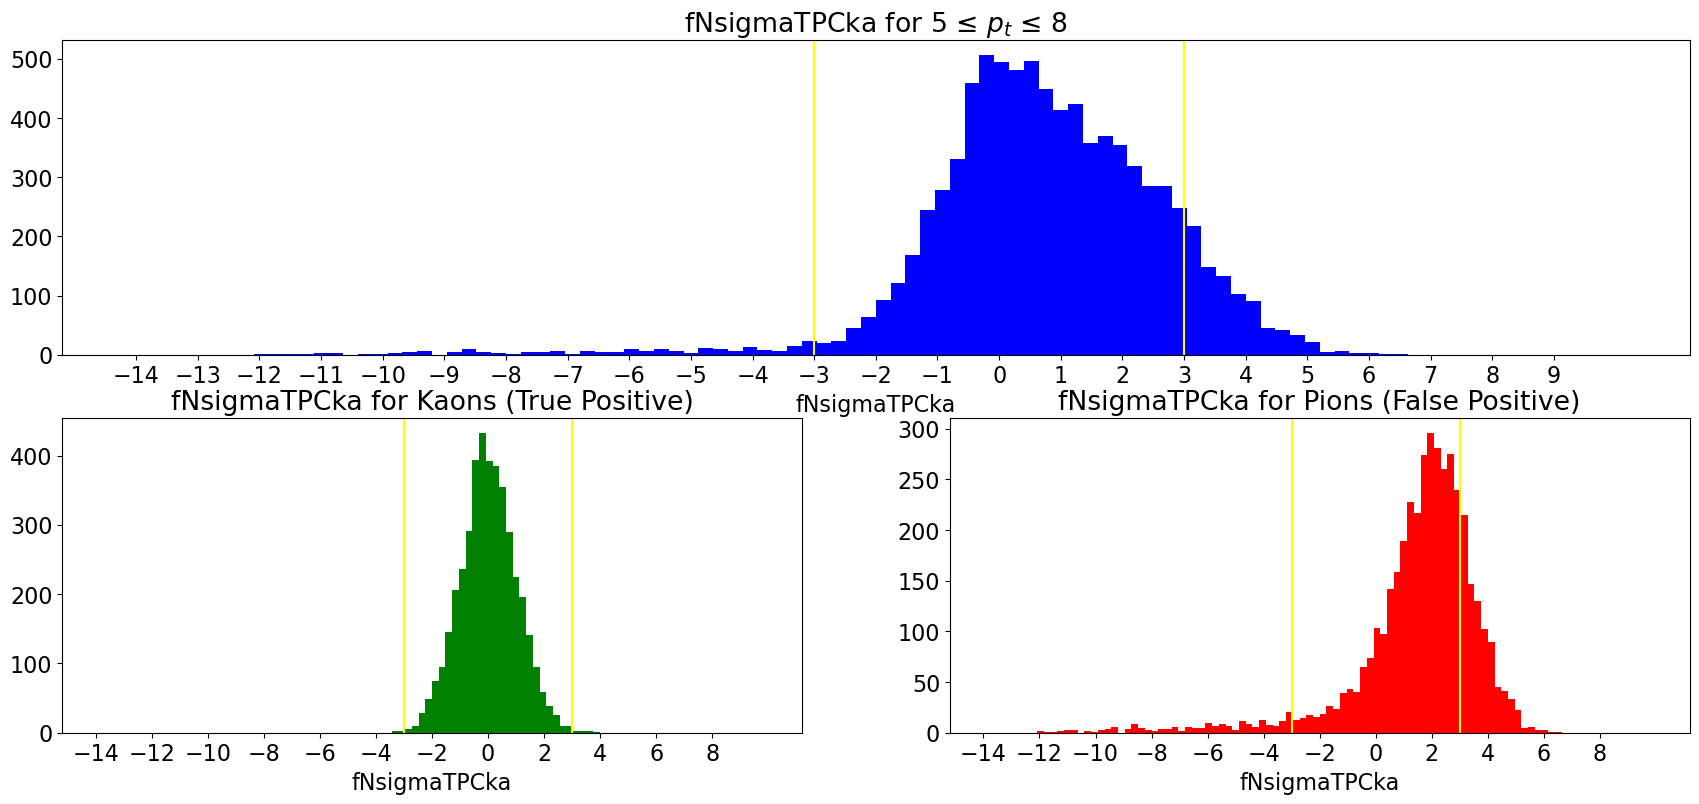

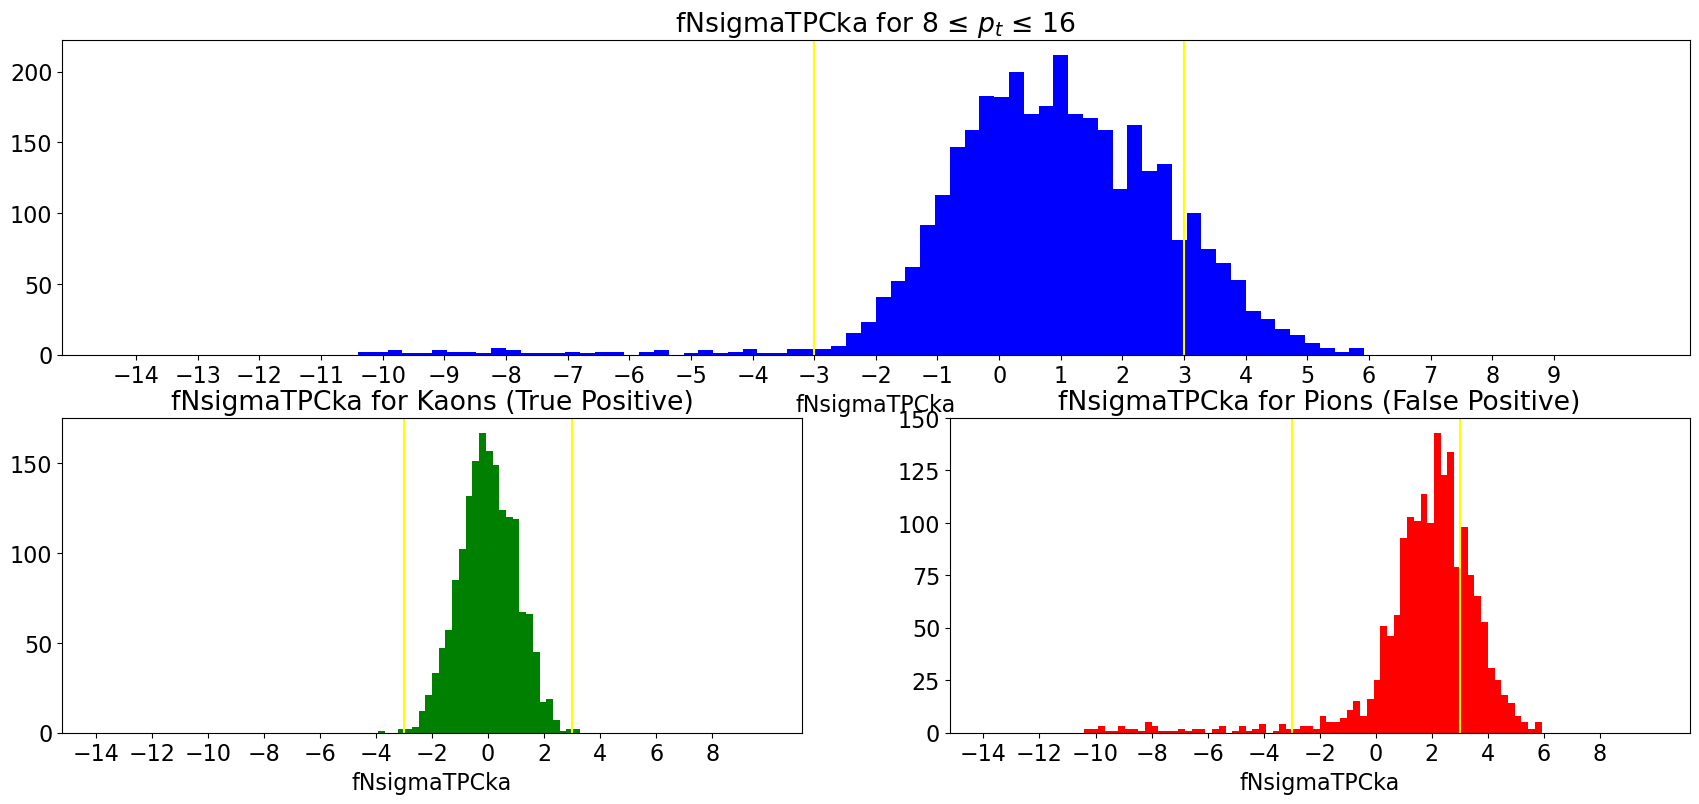

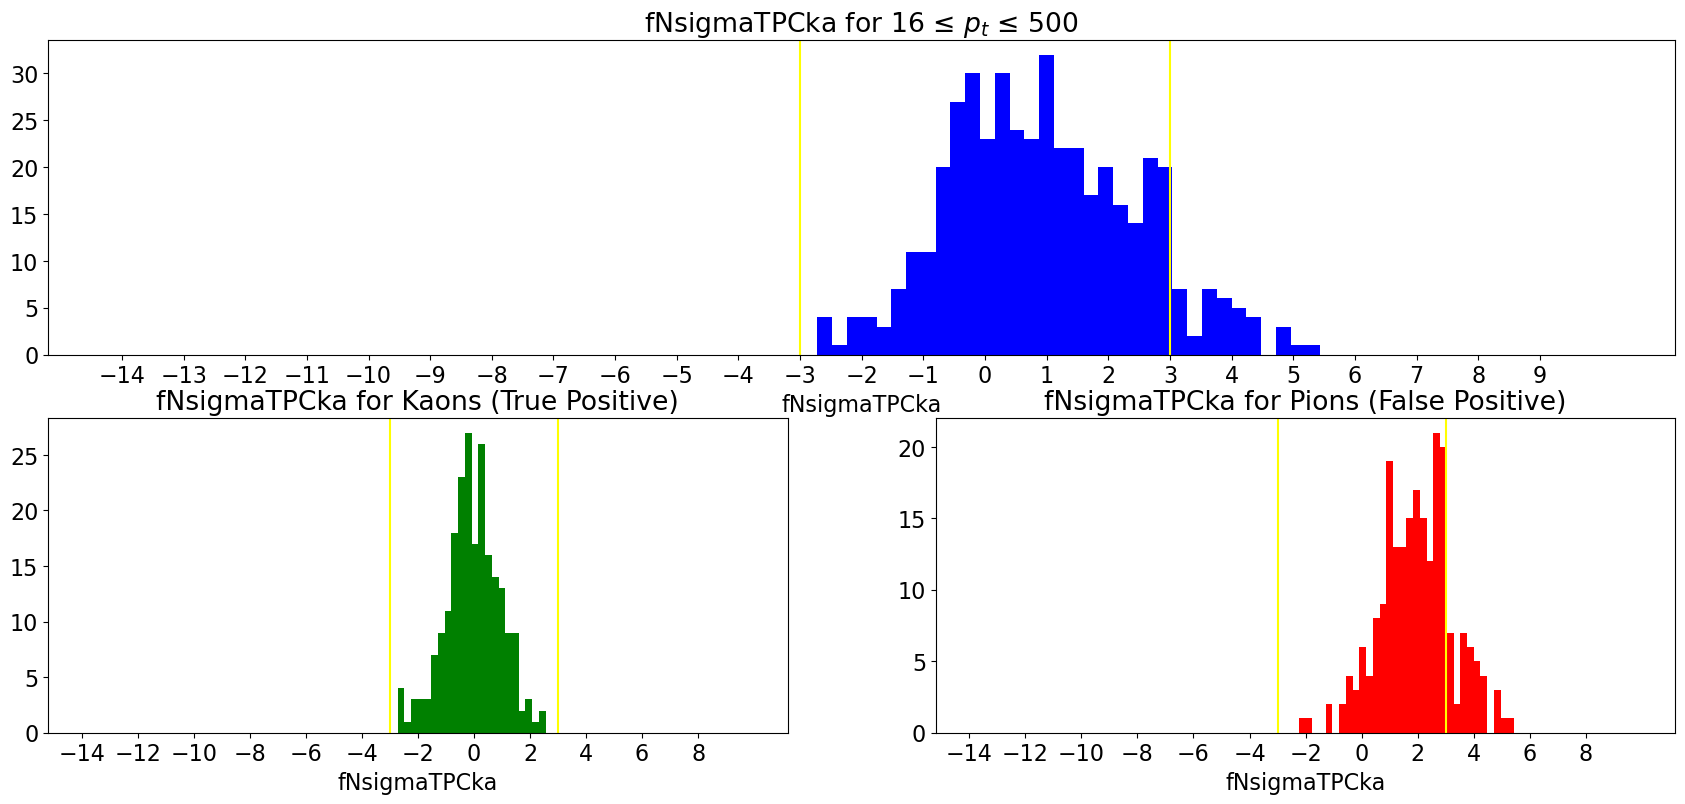

In [80]:
mosaic = [
    ["top", "top"],
    ["left", "right"]
]

MIN_TPC, MAX_TPC = -14, +10

for i in range (len(pt_slice)):
    pt_lim = pt_slice[i]
    pt_mask = df["pt"].between(pt_lim[0], pt_lim[1])

    fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
    N_BINS = 100
    axes["top"].hist(np.concat([df[pt_mask]["TPCka"],df[pt_mask]["mirror_TPCka"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
    axes["top"].set_title(f"fNsigmaTPCka for {pt_lim[0]} ≤ $p_t$ ≤ {pt_lim[1]}")
    axes["top"].set_xlabel("fNsigmaTPCka")
    axes["top"].set_xticks(np.arange(MIN_TPC, MAX_TPC, 1))
    axes["top"].set_label("Counts")
    axes["top"].axvline(x=-3, color="yellow")
    axes["top"].axvline(x=+3, color="yellow")
    
    axes["left"].hist(df[pt_mask]["TPCka"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
    axes["left"].set_title("fNsigmaTPCka for Kaons (True Positive)")
    axes["left"].set_xlabel("fNsigmaTPCka")
    axes["left"].set_xticks(np.arange(MIN_TPC, MAX_TPC, 2))
    axes["left"].set_label("Counts")
    axes["left"].axvline(x=-3, color="yellow")
    axes["left"].axvline(x=+3, color="yellow")
    
    axes["right"].hist(df[pt_mask]["mirror_TPCka"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
    axes["right"].set_title("fNsigmaTPCka for Pions (False Positive)")
    axes["right"].set_xlabel("fNsigmaTPCka")
    axes["right"].set_xticks(np.arange(MIN_TPC, MAX_TPC, 2))
    axes["right"].set_label("Counts")
    axes["right"].axvline(x=-3, color="yellow")
    axes["right"].axvline(x=+3, color="yellow")
    
    plt.show()

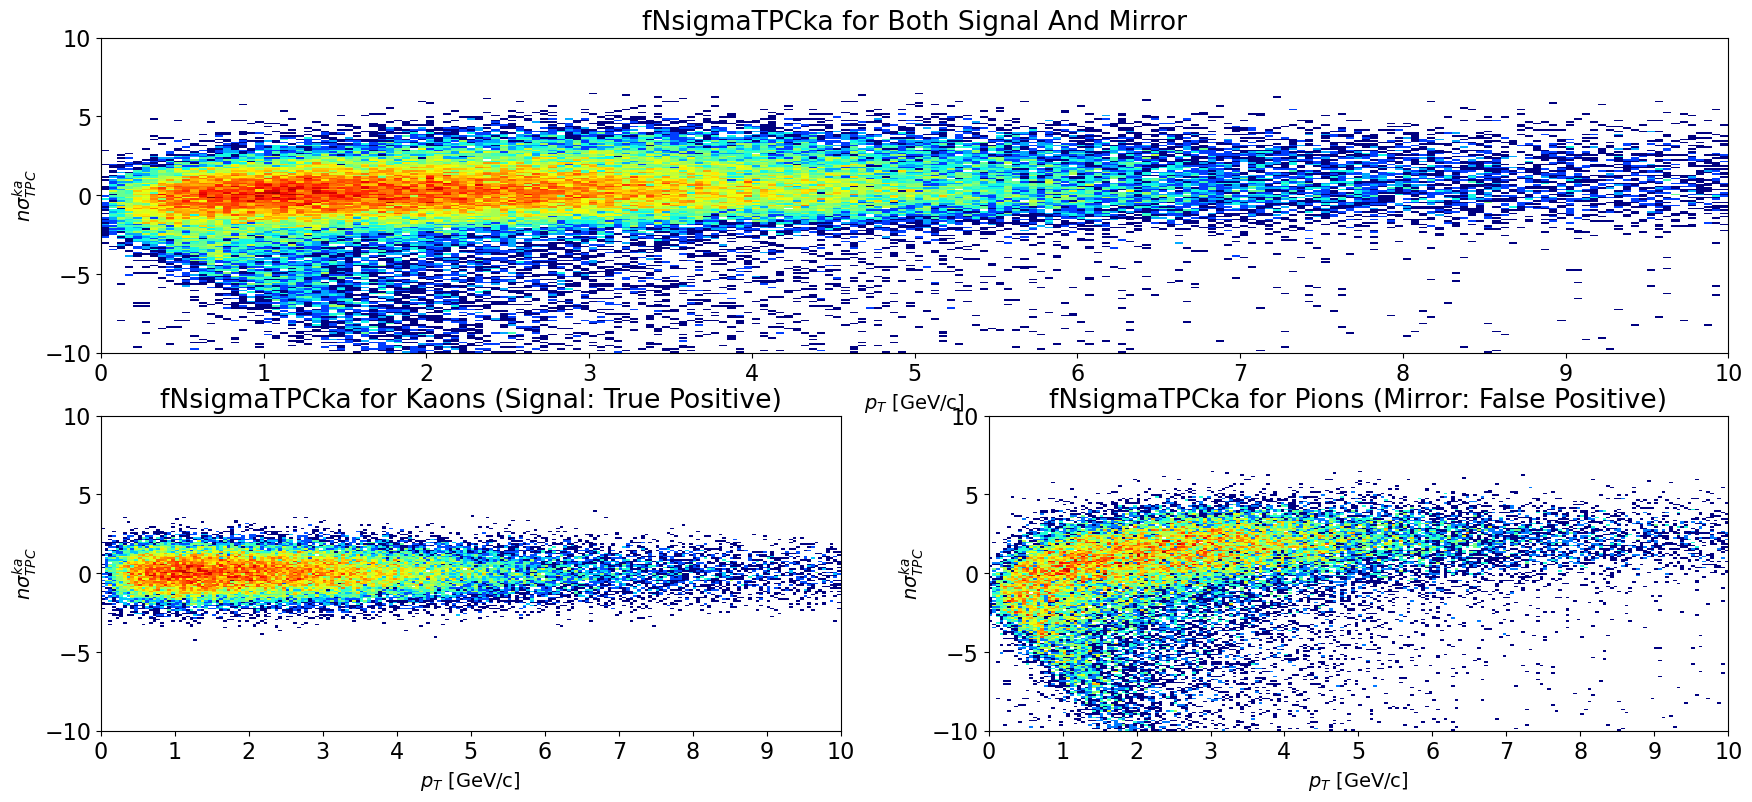

In [88]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TPC_lower, TPC_upper = -10, 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([df["pt"], df["pt"]]),
                    np.concat([df["TPCka"], df["mirror_TPCka"]]), (200, 200), cmap="jet", norm=LogNorm(), range=[[p_cut_lower,p_cut_upper],
                                                                                                                 [TPC_lower, TPC_upper]])
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCka for Both Signal And Mirror")


axes["left"].hist2d(df["pt"], df["TPCka"], (200, 200), cmap="jet", norm=LogNorm(), range=[[p_cut_lower,p_cut_upper],[TPC_lower, TPC_upper]])
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCka for Kaons (Signal: True Positive)")

axes["right"].hist2d(df["pt"], df["mirror_TPCka"], (200, 200), cmap="jet", norm=LogNorm(), range=[[p_cut_lower,p_cut_upper],[TPC_lower, TPC_upper]])
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCka for Pions (Mirror: False Positive)")

plt.show()

# TO BE CONTINUED

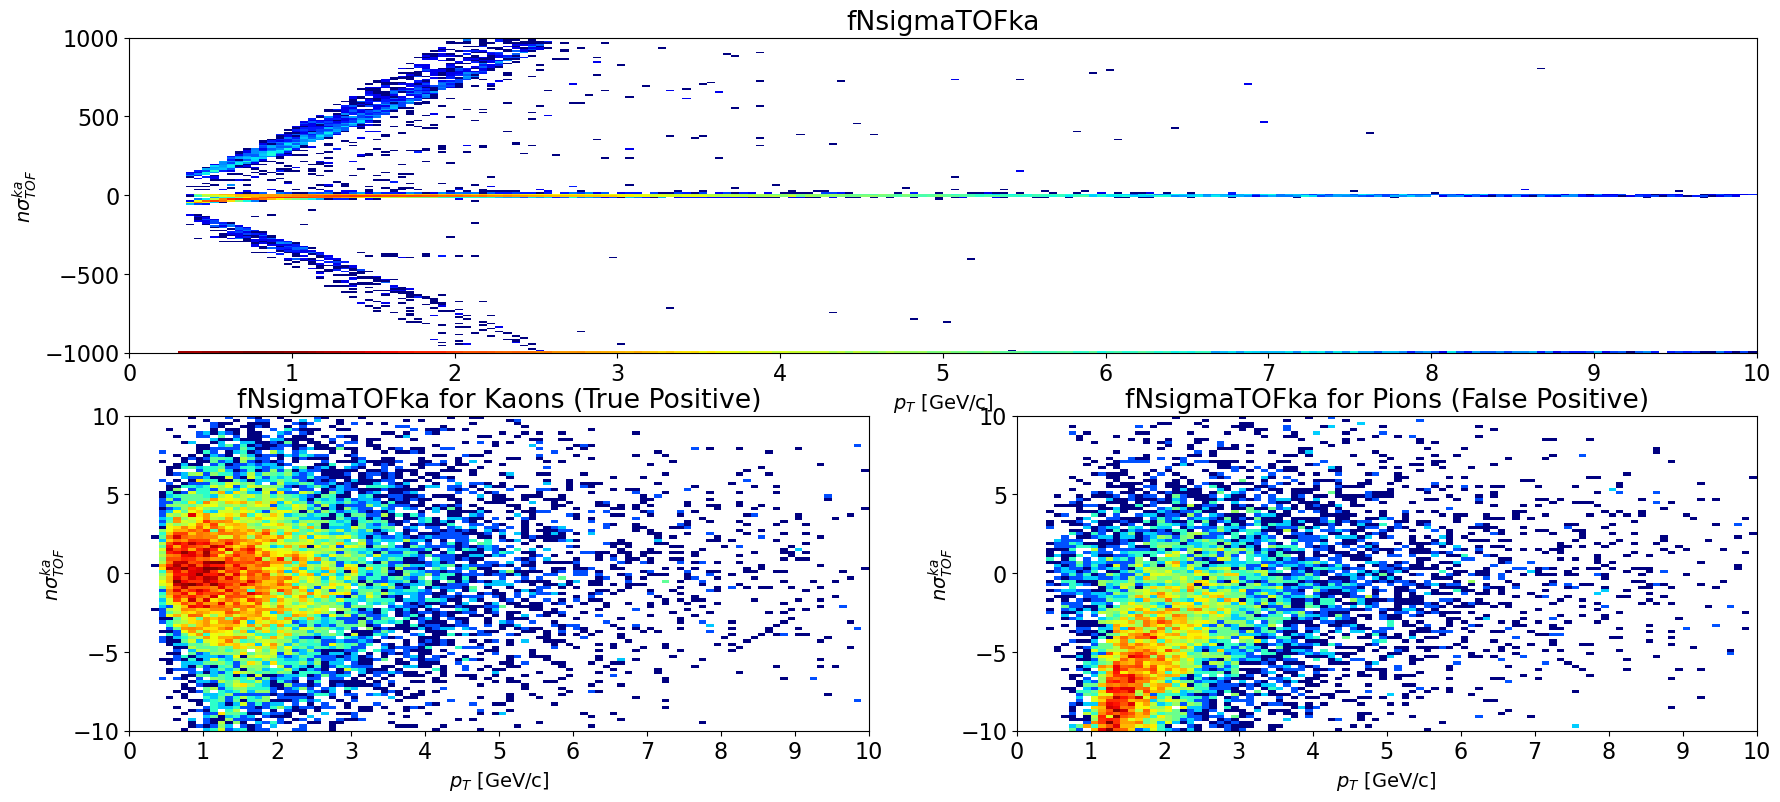

In [33]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["TOFka"], final_results["mirror_TOFka"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFka")


axes["left"].hist2d(final_results["KA_pt"], final_results["TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFka for Kaons (True Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["mirror_TOFka"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{ka}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFka for Pions (False Positive)")

plt.show()

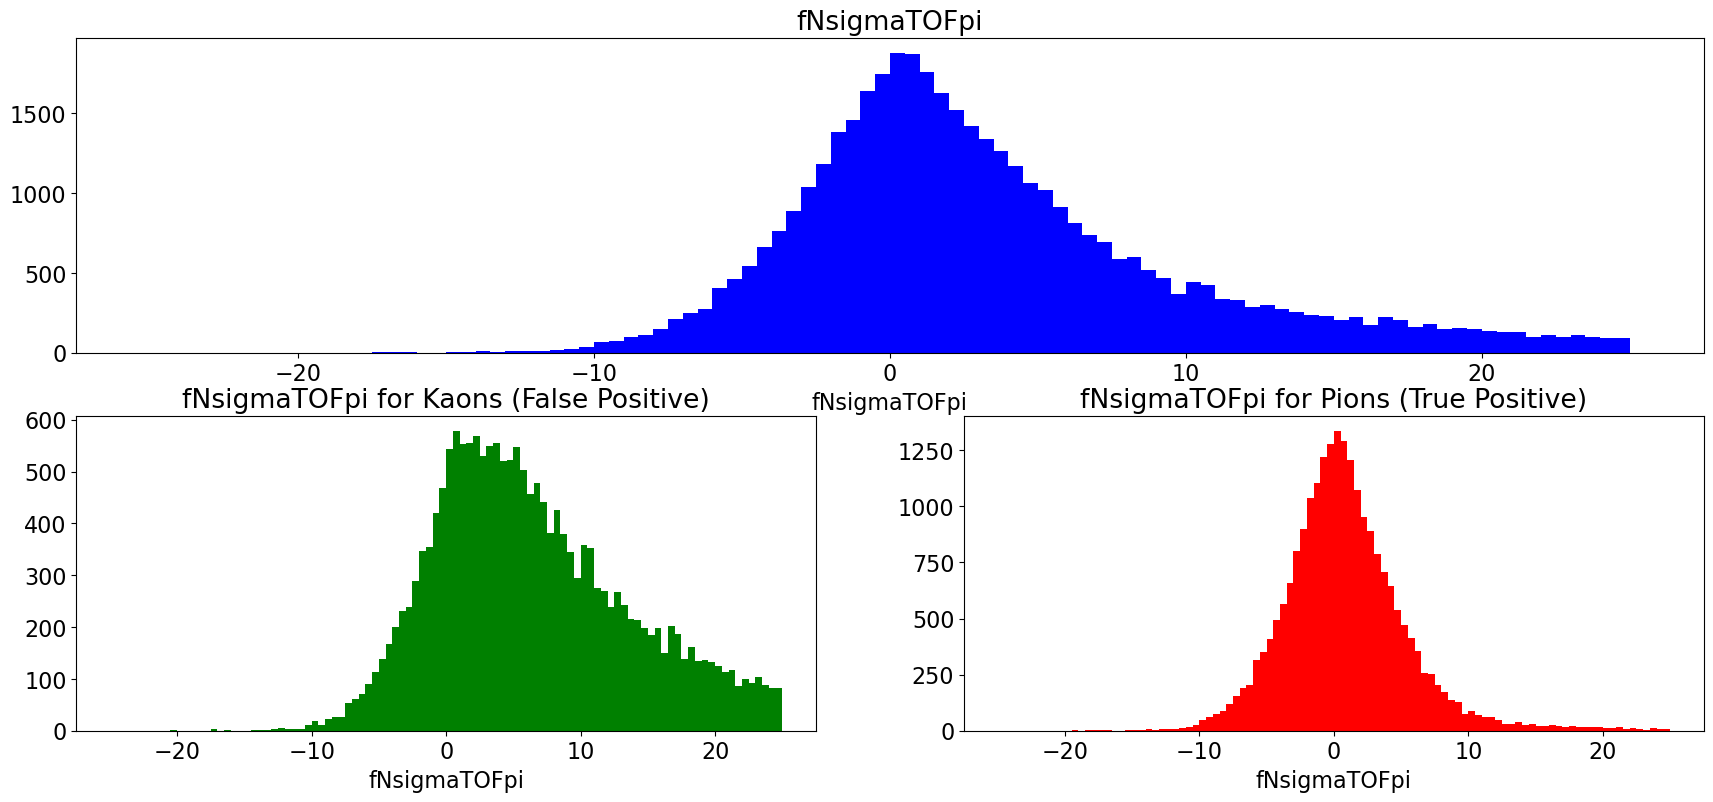

In [34]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TOF, MAX_TOF = -25, 25
axes["top"].hist(np.concat([final_results["mirror_TOFpi"],final_results["TOFpi"]]), bins=N_BINS, color="blue", range=(MIN_TOF, MAX_TOF))
axes["top"].set_title("fNsigmaTOFpi")
axes["top"].set_xlabel("fNsigmaTOFpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["mirror_TOFpi"], bins=N_BINS, color="green", range=(MIN_TOF, MAX_TOF))
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTOFpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["TOFpi"], bins=N_BINS, color="red", range=(MIN_TOF, MAX_TOF))
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTOFpi")
axes["right"].set_label("Counts")

plt.show()

---Pion only---
True Positive data remaining for -3 < TOF_PI < 3:     26.88%   (35581 rows eliminated.)
True Positive data remaining for -3 < TOF_PI < 3 or unavailable:     79.08%   (10180 rows eliminated.)

---All particles---
True&False Positive data remaining for -3 < TOF_PI < 3:     14.17%   (41770 rows eliminated.)
True&False Positive data remaining for -3 < TOF_PI < 3 or unavailable:     91.98%   (3902 rows eliminated.)


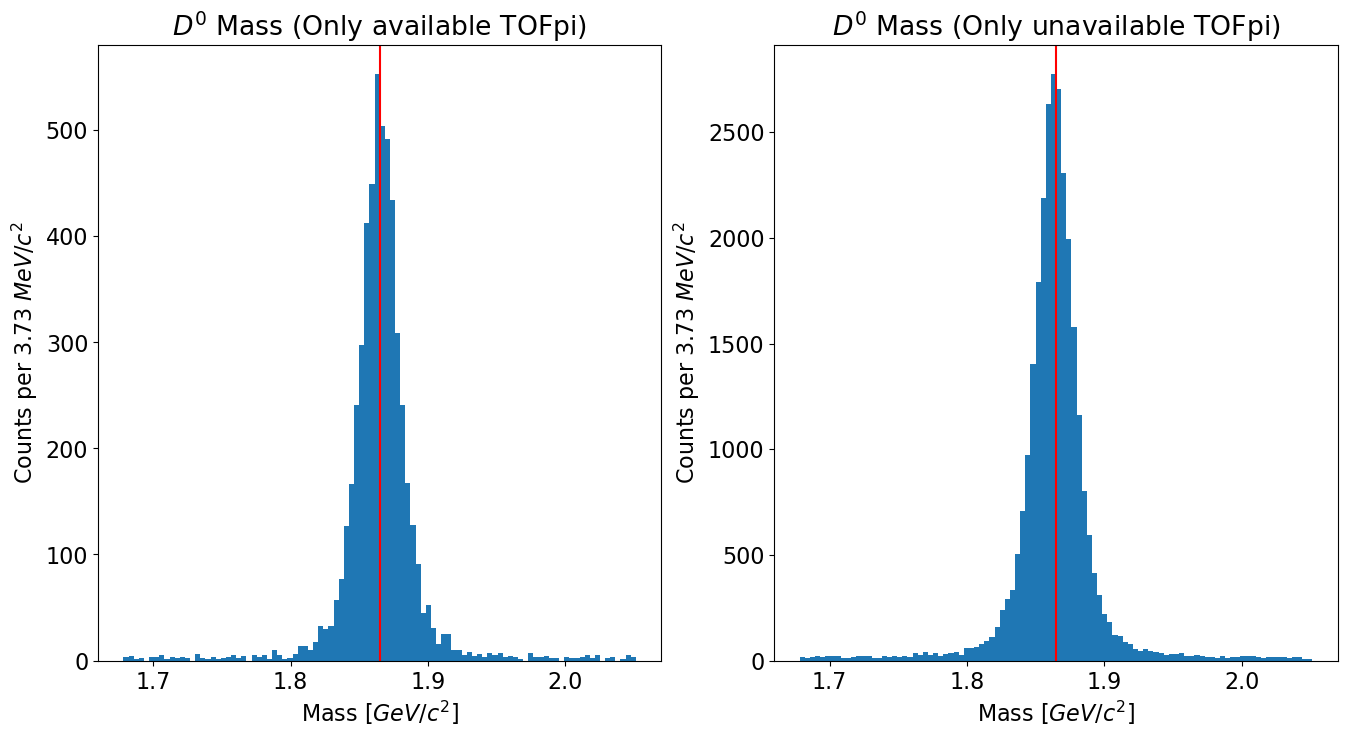

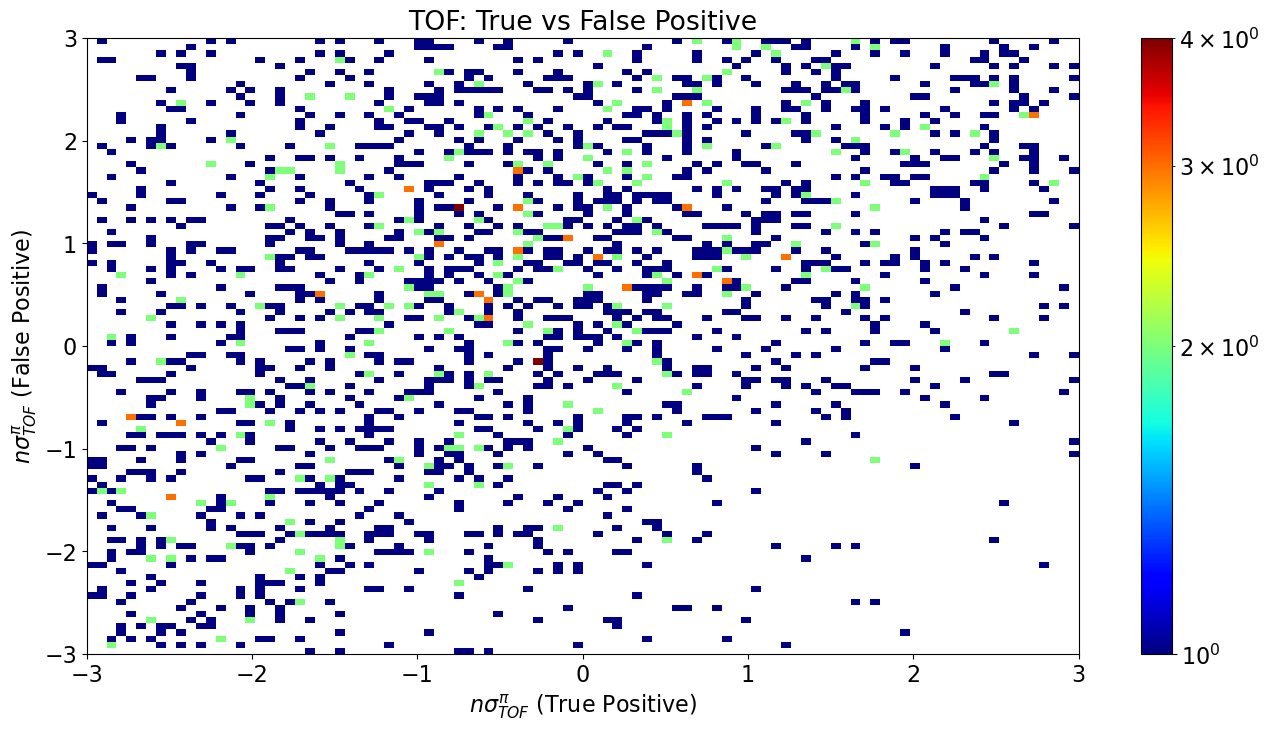

Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch: 0.14372020384678613


In [35]:
# in cut2:
# "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
# "(fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "

min_cut_TOF_PI, max_cut_TOF_PI = -3, 3
NA_TOF_PI = 998.5
start_size = len(final_results)
middle_size = sum(final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))
final_size = middle_size + sum(final_results["TOFpi"].abs() > NA_TOF_PI )
print("---Pion only---")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True Positive data remaining for {min_cut_TOF_PI} < TOF_PI < {max_cut_TOF_PI} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")
print("\n---All particles---")
middle_size = sum( ( final_results["mirror_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["mirror_TOFpi"].abs()< NA_TOF_PI) ) )
final_size = middle_size + sum( ( final_results["mirror_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["TOFpi"].abs() > NA_TOF_PI ) )
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA}:     {(middle_size/start_size)*100:.2f}%   ({start_size - middle_size} rows eliminated.)")
print(f"True&False Positive data remaining for {min_cut_TOF_KA} < TOF_PI < {max_cut_TOF_KA} or unavailable:     {(final_size/start_size)*100:.2f}%   ({start_size - final_size} rows eliminated.)")

# Are rows corresponding to unavailable TOFpi important? How does the invariant mass look without them?
only_available_TOF = final_results[( final_results["mirror_TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["TOFpi"].abs() < NA_TOF_PI) ) |
                   ( final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)  & (final_results["mirror_TOFpi"].abs()< NA_TOF_PI) )]

MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
fig, ax  = plt.subplots(1, 2, figsize=(16,8))
ax[0].hist(only_available_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[0].axvline(x=m_d0, color="red")
ax[0].set_xlabel("Mass [$GeV/c^2$]")
ax[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[0].set_title("$D^0$ Mass (Only available TOFpi)")

# only UNAVAILABLE
only_unavailable_TOF = final_results[( final_results["mirror_TOFpi"].abs() > NA_TOF_PI ) | ( final_results["TOFpi"].abs() > NA_TOF_PI ) ]
ax[1].hist(only_unavailable_TOF["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
ax[1].axvline(x=m_d0, color="red")
ax[1].set_xlabel("Mass [$GeV/c^2$]")
ax[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
ax[1].set_title("$D^0$ Mass (Only unavailable TOFpi)")

plt.show()

test = final_results[final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)]
test = test[test["mirror_TOFpi"].between(-10,10)]

# Check how the true positive and false positive are related
fig, ax = plt.subplots(figsize=(16,8))
# plt.hist2d(final_results[( final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["TOFpi"],
#            final_results[( final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI))]["mirror_TOFpi"],
#            (400, 400), cmap="jet", norm=LogNorm() )
plt.hist2d(test["TOFpi"],
           test["mirror_TOFpi"],
           (100, 100), cmap="jet", norm=LogNorm(), range=[[-3, 3], [-3, 3]] )

plt.colorbar()
plt.xlabel(r"$n\sigma^{\pi}_{TOF}$ (True Positive)")
plt.ylabel(r"$n\sigma^{\pi}_{TOF}$ (False Positive)")
#plt.ylim(-1.1*NA_TOF_PI, 1.1*NA_TOF_PI )
plt.title("TOF: True vs False Positive")
plt.show()

print("Fraction of True Positive Pions with corresponding unavailable TOF in case of particle switch:",
      sum( (final_results["TOFpi"].between(min_cut_TOF_PI, max_cut_TOF_PI)) & ( (final_results["mirror_TOFpi"].abs() > NA_TOF_PI) ) )/len(final_results) )

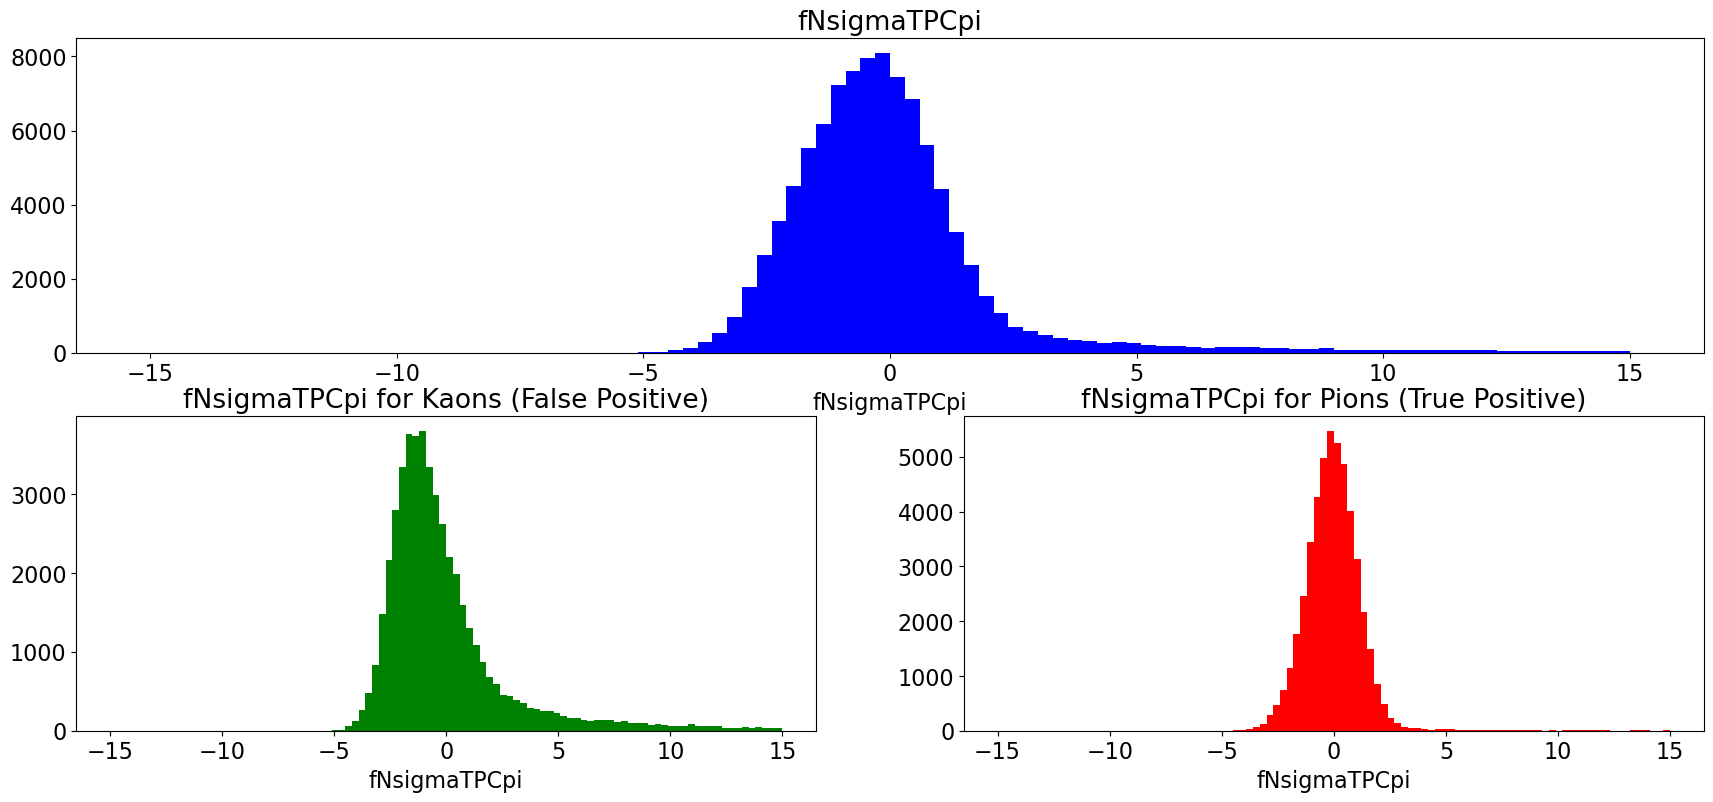

In [36]:
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
N_BINS = 100
MIN_TPC, MAX_TPC = -15, +15
axes["top"].hist(np.concat([final_results["mirror_TPCpi"],final_results["TPCpi"]]), bins=N_BINS, color="blue", range=(MIN_TPC, MAX_TPC))
axes["top"].set_title("fNsigmaTPCpi")
axes["top"].set_xlabel("fNsigmaTPCpi")
axes["top"].set_label("Counts")

axes["left"].hist(final_results["mirror_TPCpi"], bins=N_BINS, color="green", range=(MIN_TPC, MAX_TPC))
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")
axes["left"].set_xlabel("fNsigmaTPCpi")
axes["left"].set_label("Counts")

axes["right"].hist(final_results["TPCpi"], bins=N_BINS, color="red", range=(MIN_TPC, MAX_TPC))
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")
axes["right"].set_xlabel("fNsigmaTPCpi")
axes["right"].set_label("Counts")

plt.show()

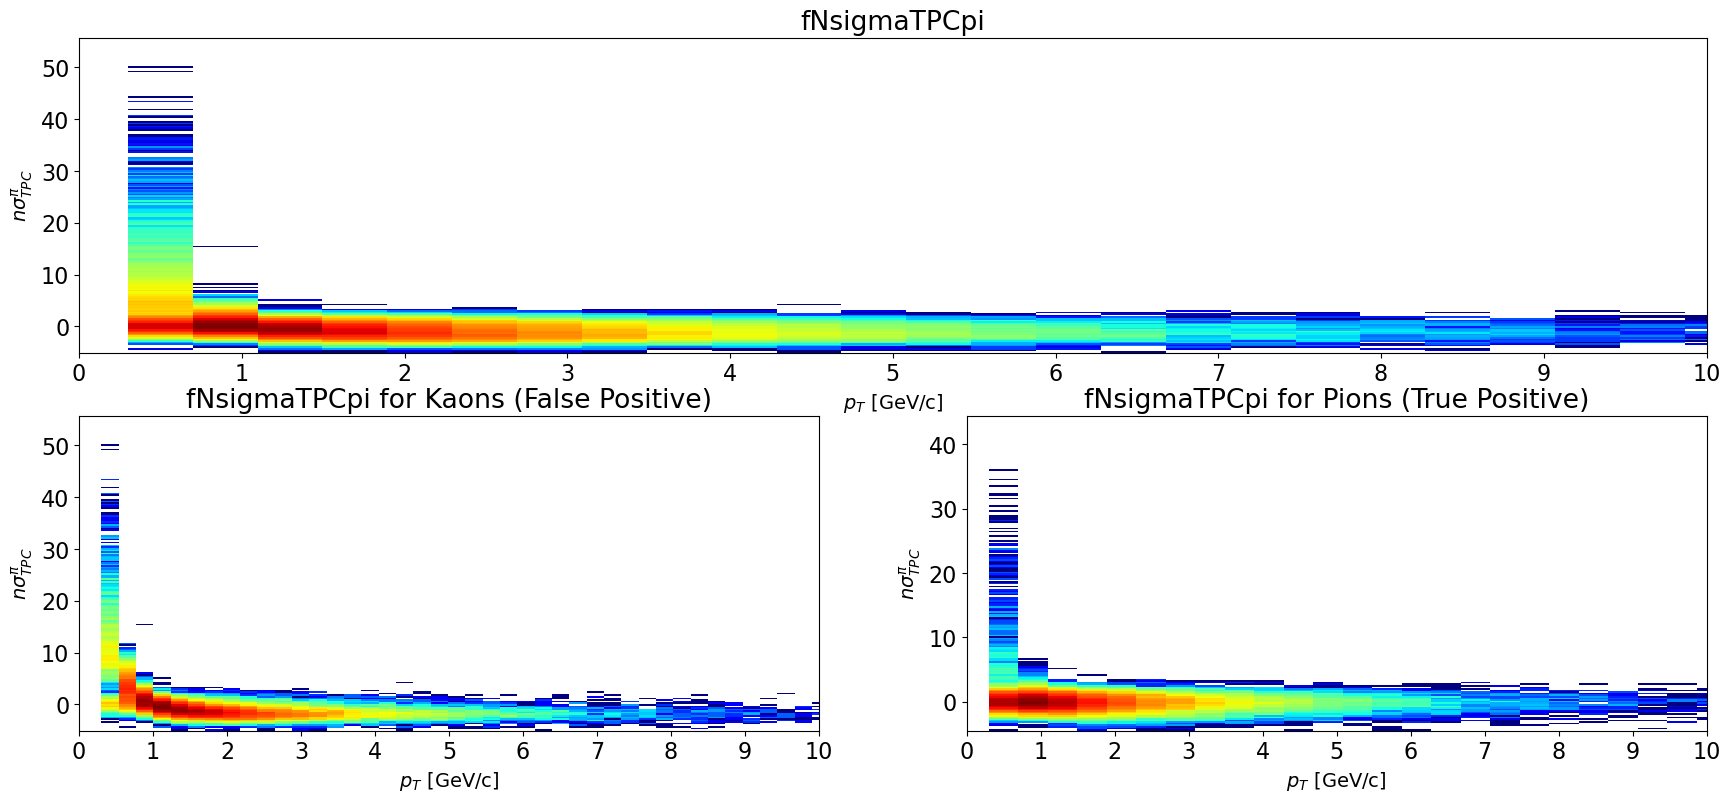

In [37]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["mirror_TPCpi"], final_results["TPCpi"]]), (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTPCpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["mirror_TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTPCpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["TPCpi"], (200, 200), cmap="jet", norm=LogNorm())
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TPC}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTPCpi for Pions (True Positive)")

plt.show()

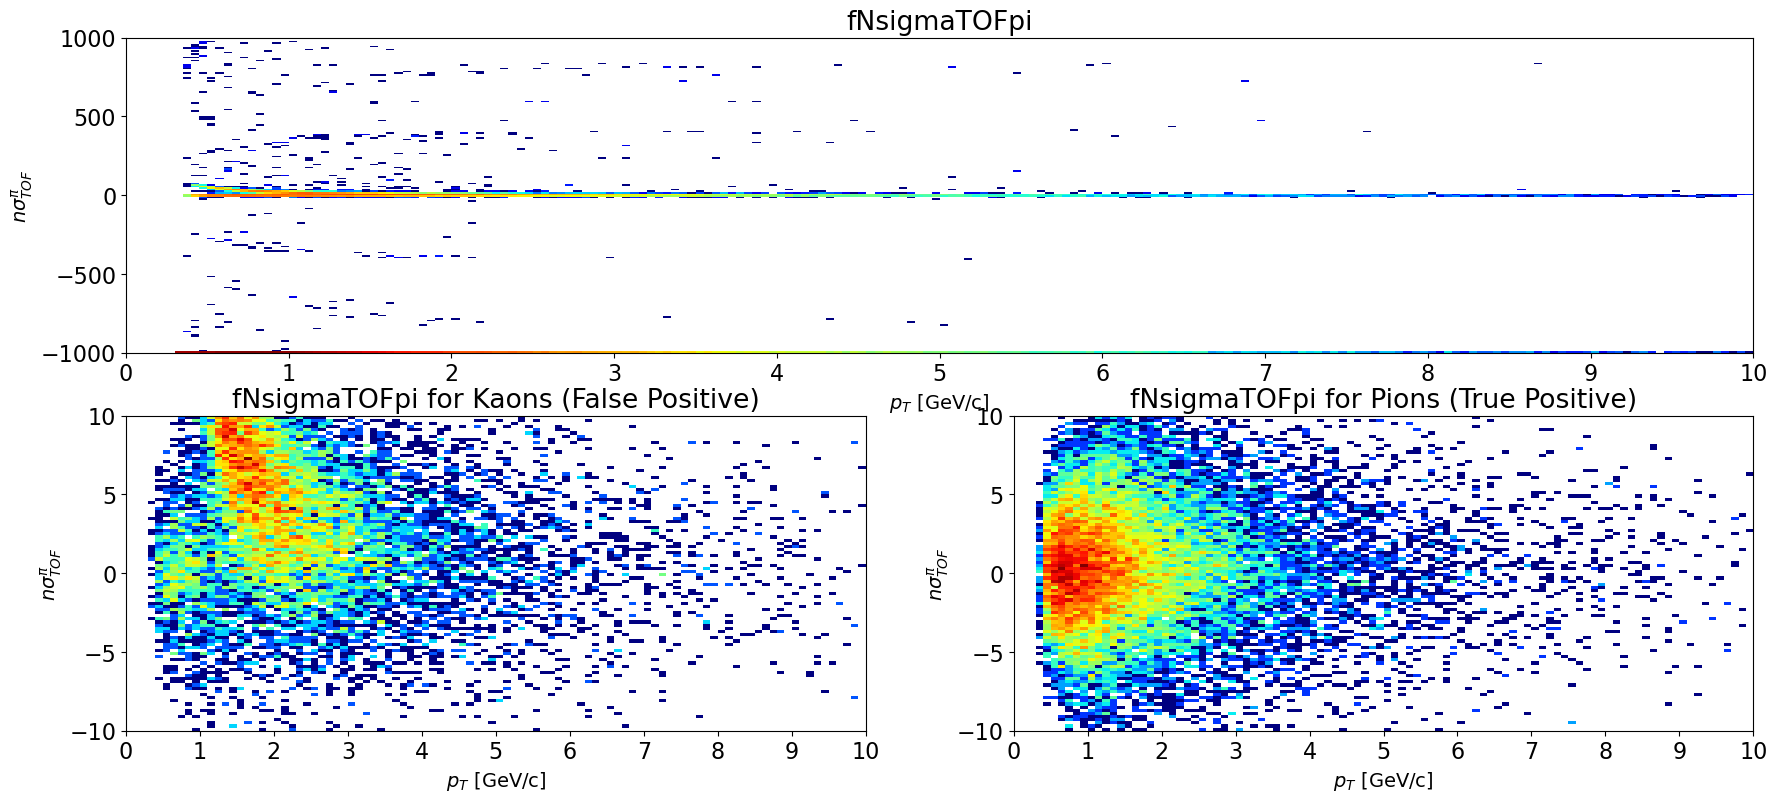

In [38]:
fs = 14
p_cut_lower = 0
p_cut_upper = 10
TOF_lower, TOF_upper = -1000, +1000
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist2d(np.concat([final_results["KA_pt"], final_results["PI_pt"]]),
                    np.concat([final_results["mirror_TOFpi"], final_results["TOFpi"]]), (200, 200), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[TOF_lower,TOF_upper]]))
# plt.colorbar(ax=axes["top"])
axes["top"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["top"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["top"].set_xlim(p_cut_lower, p_cut_upper )
axes["top"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["top"].set_title("fNsigmaTOFpi")


axes["left"].hist2d(final_results["KA_pt"], final_results["mirror_TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                    range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["left"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["left"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["left"].set_xlim(p_cut_lower, p_cut_upper )
axes["left"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["left"].set_title("fNsigmaTOFpi for Kaons (False Positive)")

axes["right"].hist2d(final_results["PI_pt"], final_results["TOFpi"], (100, 100), cmap="jet", norm=LogNorm(),
                     range = ([[p_cut_lower,p_cut_upper],[-10,10]]))
# plt.colorbar(ax=axes["left"])
axes["right"].set_xlabel(r"$p_{T}$ [GeV/c]", fontsize=fs)
axes["right"].set_ylabel(r"$n\sigma^{\pi}_{TOF}$", fontsize=fs)
axes["right"].set_xlim(p_cut_lower, p_cut_upper )
axes["right"].set_xticks(np.arange(p_cut_lower, p_cut_upper+1, 1) )
axes["right"].set_title("fNsigmaTOFpi for Pions (True Positive)")

plt.show()

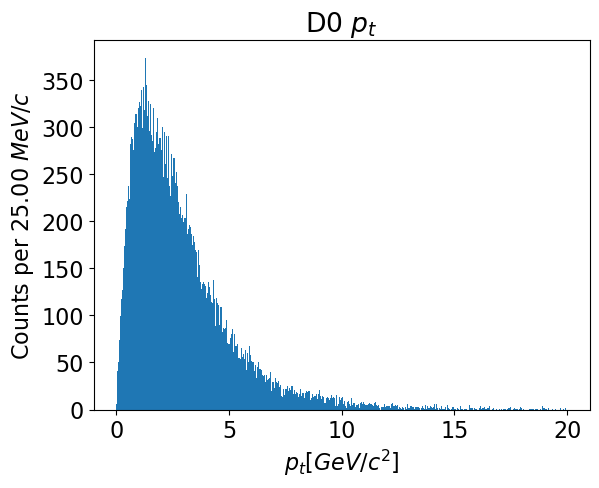

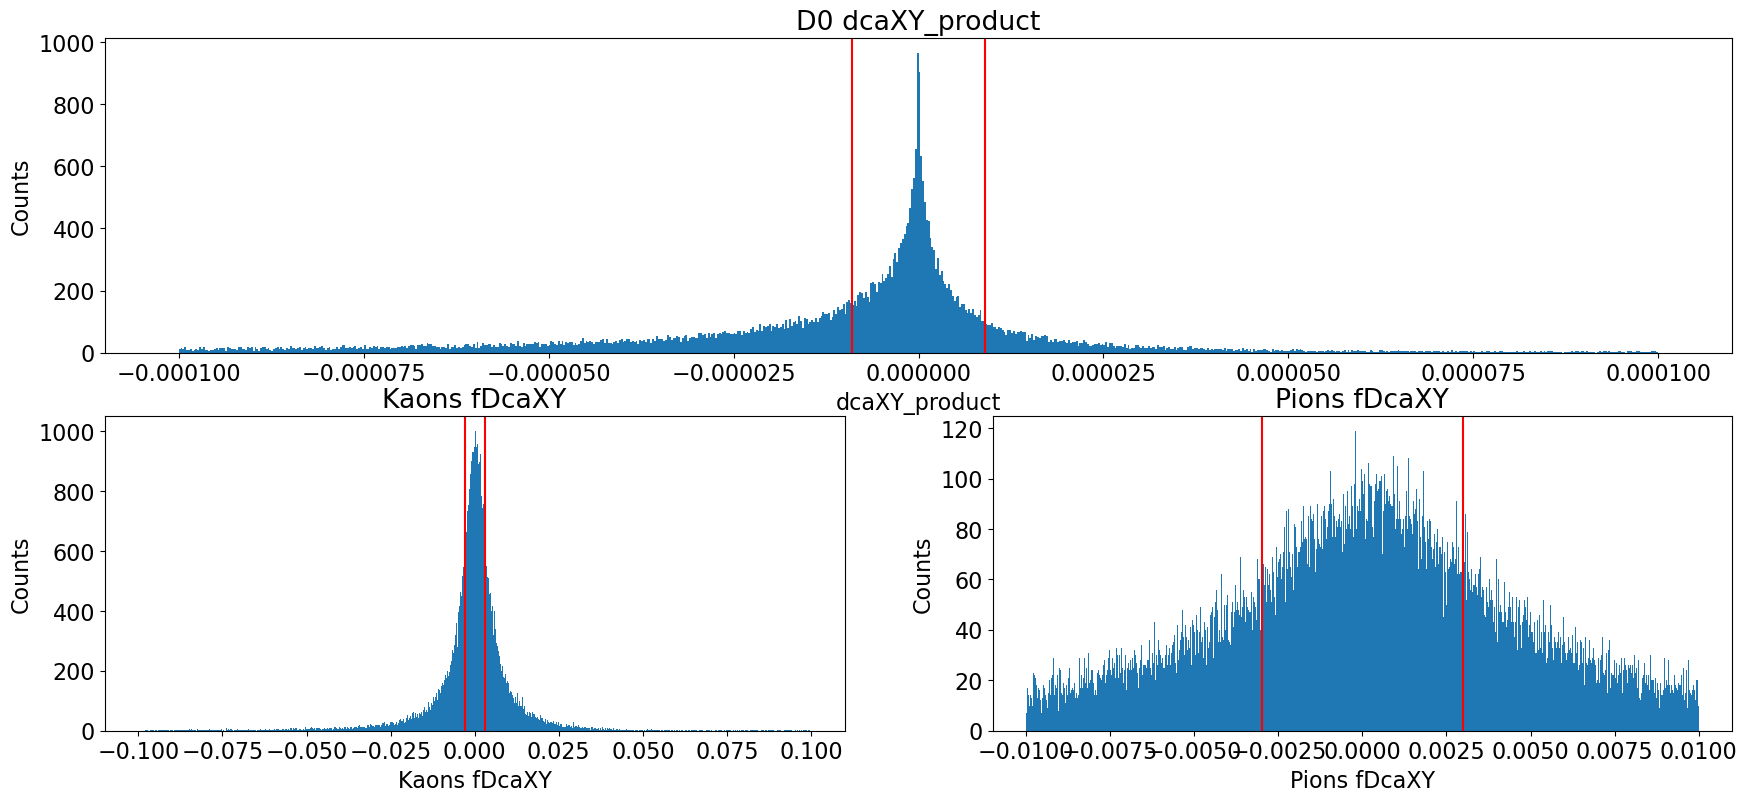

In [39]:
MIN_pt, MAX_pt = 0, 20
N_BINS = 800
plt.hist(final_results["pt"], range=(MIN_pt, MAX_pt), bins=N_BINS)
plt.xlabel("$p_t [GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_pt -  MIN_pt)/N_BINS)*1000:.2f} $MeV/c$")
plt.title("D0 $p_t$")
plt.show()

# MIN_DCAXY, MAX_DCAXY = np.quantile(final_results["dcaXY_product"], 0.01), np.quantile(final_results["dcaXY_product"], 0.99)
MIN_DCAXY, MAX_DCAXY = -1e-04, +1e-04
fig, axes = plt.subplot_mosaic(mosaic, figsize=(21, 9))
axes["top"].hist(final_results["dcaXY_product"], bins=N_BINS, range=(MIN_DCAXY, MAX_DCAXY))
axes["top"].set_xlabel("dcaXY_product")
axes["top"].set_ylabel(f"Counts")
axes["top"].set_title("D0 dcaXY_product")
axes["top"].axvline(x=-3e-03**2, color="red")
axes["top"].axvline(x=+3e-03**2, color="red")

axes["left"].hist(final_results["KA_fDcaXY"], bins=N_BINS, range=(-0.1,0.1) )
axes["left"].set_xlabel("Kaons fDcaXY")
axes["left"].set_ylabel(f"Counts")
axes["left"].set_title("Kaons fDcaXY")
axes["left"].axvline(x=-3e-03, color="red")
axes["left"].axvline(x=+3e-03, color="red")

axes["right"].hist(final_results["PI_fDcaXY"], bins=N_BINS, range=(-np.sqrt(-MIN_DCAXY),np.sqrt(MAX_DCAXY)))
axes["right"].set_xlabel("Pions fDcaXY")
axes["right"].set_ylabel(f"Counts")
axes["right"].set_title("Pions fDcaXY")
axes["right"].axvline(x=-3e-03, color="red")
axes["right"].axvline(x=+3e-03, color="red")
plt.show()

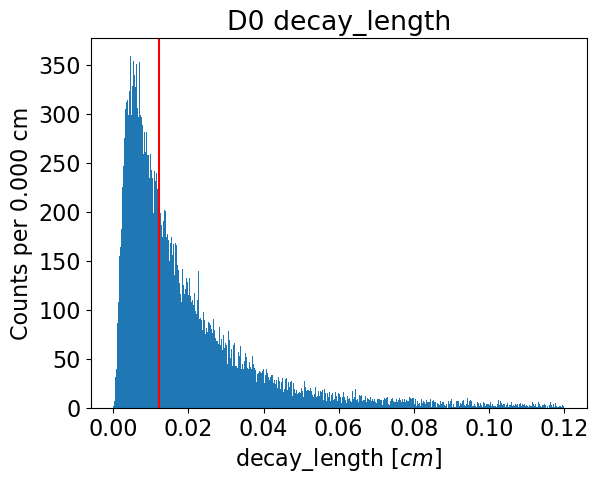

In [40]:
MIN_dl, MAX_dl = 0, 0.12
N_BINS = 800
plt.hist(final_results["decay_length"], bins=N_BINS, range=(MIN_dl, MAX_dl))
plt.xlabel("decay_length $[cm]$")
plt.ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
plt.axvline(x=1.23*10e-03, color="red")
plt.title("D0 decay_length")
plt.show()

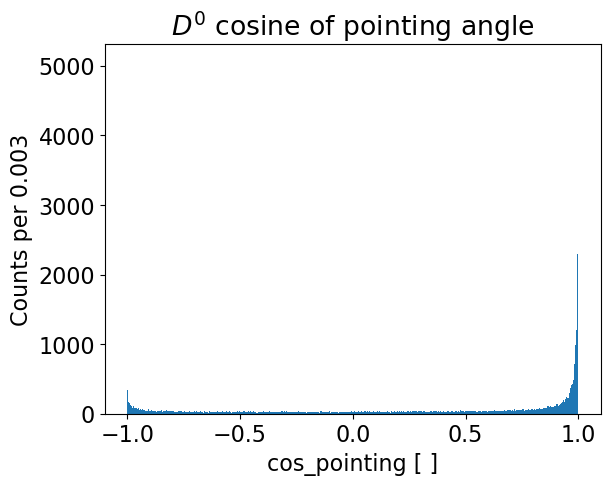

In [41]:
MIN_cos, MAX_cos = -1, 1
N_BINS = 800
plt.hist(final_results["cos_pointing"], bins=N_BINS, range=(MIN_cos, MAX_cos))
plt.xlabel("cos_pointing [ ]")
plt.ylabel(f"Counts per {((MAX_cos - MIN_cos)/N_BINS):.3f}")
plt.title("$D^0$ cosine of pointing angle")
plt.show()

In [42]:
# converting the cuts to work for this
# cut1 = (
#     "( (fNsigmaTPCpi > -3) & (fNsigmaTPCpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTPCka > -3) & (fNsigmaTPCka < 3) & (fCharge == -1) ) | "
#     "( (fPt > 0) & (fPt < 1) & (fNsigmaTPCka > -15) & (fNsigmaTPCka < 0) & (fCharge == 1) )"
# )

# # NsigmaTOF:
# sigma_limit = 3
# cut2 = (
#     "( (fNsigmaTOFpi > -3) & (fNsigmaTOFpi < 3) & (fCharge == 1) ) | "
#     "( (fNsigmaTOFka > -3) & (fNsigmaTOFka < 3) & (fCharge == -1) ) | "
#     "( (fNsigmaTOFka > 998.5) | (fNsigmaTOFka < -998.5) | (fNsigmaTOFpi > 998.5) | (fNsigmaTOFpi < -998.5) ) | "
#     "( (fPt > 0) & (fPt < 3) & (fNsigmaTOFka > -50) & (fNsigmaTOFka < 0) & (fCharge == 1) )"
# )

# # DCA_XY:
# cut3 = "( (fDcaXY > 0.0002) | (fDcaXY < -0.0002) )"


# # FINAL CUT EXPRESSION:
# cut_expression = f"({cut1}) & ({cut2}) & ({cut3})"

TOF_cut = 5
TPC_cut = 3
DCA_cut = 3e-03

cut1_A = final_results["TPCpi"].between(-TPC_cut, +TPC_cut)
cut1_B = final_results["TPCka"].between(-TPC_cut, +TPC_cut)
cut1_C = ( final_results["PI_pt"].between(0,1) ) & (final_results["TPCka"].between(-15,0) )

cut1 = cut1_A | cut1_B | cut1_C

cut2_A = final_results["TOFpi"].between(-TOF_cut, +TOF_cut)
cut2_B = final_results["TOFka"].between(-TOF_cut, +TOF_cut)
cut2_C = ( np.isclose(final_results["TOFpi"], -999.0) ) | ( np.isclose(final_results["TOFka"], -999.0) )
cut2_D = ( final_results["PI_pt"].between(0,3) ) & (final_results["TOFka"].between(-50,0) )

cut2 = cut2_A | cut2_B | cut2_C | cut2_D

cut3 = ( final_results["KA_fDcaXY"].abs() >= DCA_cut ) & ( final_results["PI_fDcaXY"].abs() >= DCA_cut )

final_cut = cut1 & cut2 & cut3

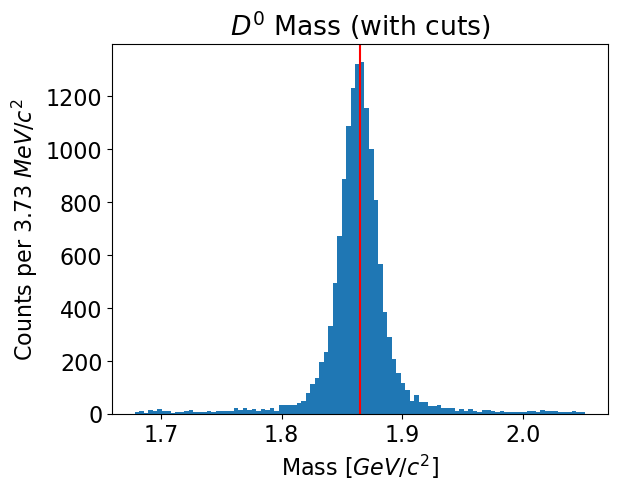

Amount of remaining data after cuts: 36.73%


,1A,1B,1C,2A,2B,2C,2D,TOT_1,TOT_2,TOT_3,FINAL
0,0.979656,0.9581,0.178017,0.367582,0.31436,0.751993,0.195463,0.999959,0.959457,0.394213,0.367253


In [43]:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 100
plt.hist(final_results[final_cut]["inv_mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS))
plt.axvline(x=m_d0, color="red")
plt.xlabel("Mass [$GeV/c^2$]")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
plt.title("$D^0$ Mass (with cuts)")
#plt.savefig("D0_Mass_MC.png")
plt.show()
print(f"Amount of remaining data after cuts: {sum(final_cut)/len(final_results)*100:.2f}%")

cut_effect = pd.DataFrame({
    "1A": sum(cut1_A)/len(final_results),
    "1B": sum(cut1_B)/len(final_results),
    "1C": sum(cut1_C)/len(final_results),
    "2A": sum(cut2_A)/len(final_results),
    "2B": sum(cut2_B)/len(final_results),
    "2C": sum(cut2_C)/len(final_results),
    "2D": sum(cut2_D)/len(final_results),
    "TOT_1": sum(cut1)/len(final_results),
    "TOT_2": sum(cut2)/len(final_results),
    "TOT_3":  sum(cut3)/len(final_results),
    "FINAL": sum(final_cut)/len(final_results)
}, index=[0])
display(cut_effect)

In [44]:
final_results

,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
0,D0,66,-1.321097e-06,1.860440,1.977302,4.713480,2.997023,0.012976,0.964281,3.461287,...,1.594764,-0.008085,-2.909040,-999.000000,1.663699,-6.424459,211.0,-321.0,115539.0,115539.0
1,Anti-D0,82,-2.573491e-06,1.844297,2.004790,2.841766,-0.914937,0.004732,0.896998,2.354507,...,-1.417414,0.001744,-1.395078,2.593124,-2.152633,-24.600008,321.0,-211.0,153753.0,153753.0
2,D0,157,-7.651521e-06,1.888459,2.017118,2.195002,-0.055988,0.005348,0.617997,2.055277,...,-999.000000,-0.001751,-2.549568,-5.819521,-3.810798,-999.000000,211.0,-321.0,278327.0,278327.0
3,Neither,235,3.273250e-05,2.686728,2.851430,0.623883,0.007970,0.037103,0.784885,0.927068,...,3.163080,0.003012,-0.019558,2.644639,1.002099,-6.320635,211.0,-211.0,405591.0,406104.0
4,Neither,235,-5.612233e-06,1.008210,1.386123,2.550970,-0.787728,0.008647,0.963760,1.277296,...,3.163080,0.003012,0.573825,-999.000000,1.002099,-6.320635,211.0,-211.0,405769.0,406104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48659,Neither,3246794,-6.777133e-06,2.193486,2.395530,3.056641,0.974706,0.011953,0.783787,1.522426,...,-4.846432,-0.009737,0.743161,-4.576275,1.731738,-8.945634,211.0,-211.0,2573489.0,2573087.0
48660,Anti-D0,3246794,-2.798869e-05,1.879726,2.060368,9.072687,4.670576,0.044078,0.999820,6.933897,...,-4.846432,-0.009737,-3.234479,-999.000000,1.731738,-8.945634,321.0,-211.0,2573087.0,2573087.0
48661,Anti-D0,3246798,4.130047e-07,1.832013,1.742938,3.655294,0.484583,0.005543,-0.962037,1.233602,...,0.952291,-0.000198,-1.337071,10.705864,3.551570,-2.329287,321.0,-211.0,2583848.0,2583848.0
48662,D0,3246866,-1.465046e-06,1.849266,1.876302,3.204147,0.819941,0.004777,0.588302,1.788209,...,-999.000000,-0.001706,-0.398352,-999.000000,2.473562,-999.000000,211.0,-321.0,2720685.0,2720685.0


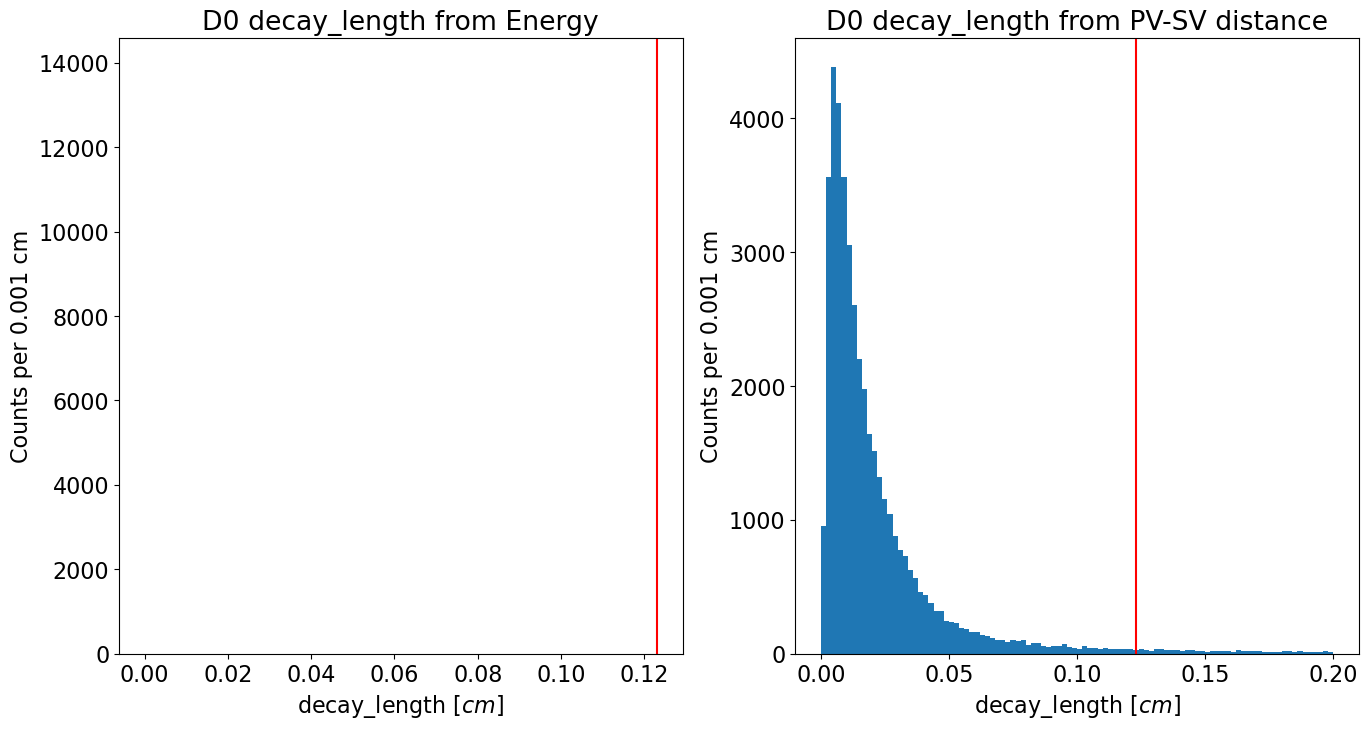

In [45]:
c = 299_792_458
tau = 410e-15

extra = pd.DataFrame({
    "P": np.sqrt( final_results["pt"]**2 + final_results["pz"]**2 )
})
extra["E"] = np.sqrt(final_results["inv_mass"]**2*c**4 + extra["P"]**2*c**2)
extra["Beta"] = extra["P"]*c/extra["E"]
gamma = 1.0/np.sqrt(1-extra["Beta"]**2)

ctau = c*tau
extra["L"] =  extra["Beta"]*gamma*ctau
fix, ax = plt.subplots(1,2, figsize=(16,8))
ax[0].hist(extra["L"], bins=N_BINS)
ax[0].set_xlabel("decay_length $[cm]$")
ax[0].set_ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
ax[0].axvline(x=1.23*10e-02, color="red")
ax[0].set_title("D0 decay_length from Energy")

ax[1].hist(final_results["decay_length"], bins=N_BINS, range=(0, 0.20))
ax[1].set_xlabel("decay_length $[cm]$")
ax[1].set_ylabel(f"Counts per {((MAX_dl - MIN_dl)/N_BINS):.3f} cm")
ax[1].axvline(x=1.23*10e-02, color="red")
ax[1].set_title("D0 decay_length from PV-SV distance")
plt.show()

In [46]:
len(final_results[ final_results["TOFpi"].between(-TOF_cut, +TOF_cut) | final_results["TOFka"].between(-TOF_cut, +TOF_cut) ])/len(final_results)

0.5417968107841525

In [47]:
final_results[final_cut]

,Nature,collision_index,dcaXY_product,inv_mass,mirror_mass,pt,pz,decay_length,cos_pointing,KA_pt,...,TOFpi,PI_fDcaXY,mirror_TPCpi,mirror_TOFpi,mirror_TPCka,mirror_TOFka,PDG+,PDG-,MotherIndex+,MotherIndex-
3,Neither,235,0.000033,2.686728,2.851430,0.623883,0.007970,0.037103,0.784885,0.927068,...,3.163080,0.003012,-0.019558,2.644639,1.002099,-6.320635,211.0,-211.0,405591.0,406104.0
5,Anti-D0,235,-0.000032,1.865765,1.753442,0.909008,-1.116480,0.083311,0.598480,0.476199,...,3.163080,0.003012,7.736825,-999.000000,1.002099,-6.320635,321.0,-211.0,406104.0,406104.0
6,Anti-D0,400,-0.000051,1.854659,1.840704,0.719853,0.158138,0.009095,0.947473,0.809813,...,-3.846736,-0.007479,0.535939,24.063946,1.423025,-23.709217,321.0,-211.0,709437.0,709437.0
7,Neither,400,0.000055,2.974109,2.770984,2.138142,0.479352,0.017086,-0.705076,0.809813,...,3.642885,0.008032,0.535939,24.063946,-1.496463,-0.032347,321.0,-321.0,709437.0,709749.0
9,Anti-D0,478,-0.000066,1.882078,1.796934,1.747342,0.082626,0.012238,0.964476,0.642213,...,-2.704329,-0.007051,3.067116,30.254293,1.538267,-9.537827,321.0,-211.0,850632.0,850632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48653,Neither,3246159,-0.000044,1.600683,1.956797,1.822621,-0.338738,0.014826,0.147904,0.440285,...,-999.000000,-0.010677,-0.012215,1.292366,1.080442,-999.000000,211.0,-211.0,1438245.0,1438260.0
48654,Anti-D0,3246159,-0.000265,1.856802,1.789291,2.573213,0.028112,0.040206,0.995061,0.971963,...,-999.000000,-0.010677,-0.396441,-999.000000,1.080442,-999.000000,321.0,-211.0,1438260.0,1438260.0
48655,Neither,3246186,-0.000013,2.375271,2.561483,1.180496,-0.663263,0.005851,-0.837255,1.116984,...,-999.000000,-0.004275,0.445158,-9.622657,2.119362,-999.000000,211.0,-211.0,1489521.0,1490167.0
48656,Anti-D0,3246245,-0.000020,1.851839,1.784632,0.503594,-0.191365,0.031559,0.937153,0.498951,...,-999.000000,-0.006575,4.556105,52.625698,0.383722,-999.000000,321.0,-211.0,1590714.0,1590714.0
